# Exercise 5 — Collecting Input Data for a Groundwater Model in Norway

This notebook was made to collect all the data that you need to run a groundwater flow for a catchment in Norway. It reads data from open-data services and stores this as raster files in a directory. These raster files are used by a separate notebook to construct and run a groundwater model of the catchmet. 

The code is written in a step-by-step style so you can see clearly how each dataset is downloaded, cleaned, rasterized, and checked before modelling.

## Workflow:

1. First go to the NVE atlas: https://atlas.nve.no/Html5Viewer/index.html?viewer=nveatlas# 
2. Click on `vassdrag`-> `nedborfeld` and keep `REGINE_enhet` on
3. Find the `vassdragsNr` by using the identify tool and clicking on the catchment that you want to work with and then selecting `view additional details`. For example the vassdragsNr for central Bergen is `056.5`
4. Enter the number in the `REGINE_ID`variable in this notebook in Section 1 below
5. Run this notebook to download all the required data
6. The notebook will warn you if there are no groundwater data available for your catchment. If that is the case you unfortuantely have to try another catchment.
7. Inspect the figures below each section to make sure all data looks good and reasonable.


## Data sources

The data that are needed consists of a catchment boundary, which will form the boundary of the groundwater model, the location of rivers, lakes and the sea, the elevation of the land surface, and the geology of area. Groundwater recharge is based on existing country-wide estimates. The table below gives an overview of the data that is downloaded and stored for later use in the groundwater model:

| Layer | Provider | Service |
|---|---|---|
| Catchment boundary | NVE | ArcGIS FeatureServer REST |
| Digital elevation model | Kartverket | ArcGIS ImageServer (hoydedata.no) |
| Lakes and rivers | NVE | ArcGIS REST (nve.geodataonline.no) |
| Geology | NGU | OGC API Features (geo.ngu.no) |
| Sea boundary | OpenStreetMap | Overpass API (`natural=coastline`) |


## Output files 

The output of this notebook consists of the following files. These area all in geotiff format, so if you want you can inspect them with standard GIS software like ArcGIS or the free alternative QGIS (https://qgis.org/)

| File | Format | Contents |
|---|---|---|
| `dem.tif` | Float32 GeoTIFF | Surface elevation (metres), with sea cells forced to 0 m — Kartverket DTM10/DTM50 + OSM sea mask |
| `surface_water.tif` | Int16 GeoTIFF | 0 = no water · 1 = lake · 2 = river · 3 = sea |
| `geology.tif` | Int16 GeoTIFF | Integer ID per lithology |
| `geology_legend.csv` | CSV | Maps integer IDs → rock type, age, description |
| `sea.tif` | Int16 GeoTIFF | 0 = land · 1 = sea — OSM coastline |

## Install modules (if needed)

In [36]:
# Run this cell once to install required packages, then comment it out again.
# !pip install geopandas rasterio owslib pyproj shapely contextily matplotlib numpy requests pandas

## Import modules

In [ ]:
import re
import warnings
import io
import urllib.parse
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import requests
import pandas as pd

import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.features
import rasterio.transform
import rasterio.enums
from rasterio.crs import CRS as RasterioCRS
from pyproj import Transformer

from shapely.geometry import box, mapping, MultiPolygon, Polygon
from shapely.ops import polygonize, linemerge, unary_union

print("All packages loaded successfully.")
print(f"  geopandas : {gpd.__version__}")
print(f"  rasterio  : {rasterio.__version__}")


All packages loaded successfully.
  geopandas : 1.1.1
  rasterio  : 1.4.3


## Parameters and locations of web data

In [38]:

# ─── Output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = Path("data/model_input")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Coordinate reference system ──────────────────────────────────────────────
# EPSG:25833 = UTM Zone 33N — the standard CRS for Norwegian datasets
CRS = "EPSG:25833"

# ─── API endpoints (open data, no authentication required) ────────────────────
NVE_CATCHMENT_URL = "https://nve.geodataonline.no/arcgis/rest/services/Nedborfelt1/MapServer/3/query"
HOYDEDATA_DTM_URL = "https://hoydedata.no/arcgis/rest/services/DTM/ImageServer/exportImage"
NVE_LAKES_URL     = "https://nve.geodataonline.no/arcgis/rest/services/Innsjodatabase2/MapServer/5/query"
NVE_RIVERS_URL    = "https://nve.geodataonline.no/arcgis/rest/services/Elvenett1/MapServer/2/query"
NGU_LOSM_URL      = "https://geo.ngu.no/api/features/losmasseregionalt/collections/losmasseflate/items"
OSM_OVERPASS_URL  = "https://overpass-api.de/api/interpreter"

print("CRS:", CRS)
print("Output directory:", OUTPUT_DIR.resolve())

CRS: EPSG:25833
Output directory: /Users/elcopone/werk/python_scripts/GEOV212_Hydrogeology_test/data/model_input


## Section 1 — Catchment Selection

We are going to base our model runs on surface water catchments. This is technically not 100% correct, because surface water catchments are not the same as groundwater catchments. However, data on groundwater catchments are unavailable, and the two are often reasonably close, because the watertable tends to follow the topography.

In the section below you can select a catchment for which you would like to model groundwater flow. 

We will use a catchment database maintained by NVE (Norwegian Water Resources and
Energy Directorate). Each catchment has:

- a **name** (`vassdragsnavn`), e.g. `"Nidelva"`, `"Lågen"`, `"Begna"`
- a **REGINE ID** (`vassdragsnr`), e.g. `"123.Z"` — visible at [nve.no/kart](https://nve.no/kart)

In the cell below, set either `CATCHMENT_NAME` (partial match, case-insensitive) **or**
`REGINE_ID` (exact). Comment out the option you are not using.

> **Tip**: Browse and find your catchment at [NVE Atlas](https://atlas.nve.no) —
> look for the *Nedbørfelt* layer. The REGINE ID is shown in the feature info panel.

In [39]:
# ── Choose ONE option — comment out the other ─────────────────────────────────

#CATCHMENT_NAME = "Nidelva"      # partial name match, case-insensitive
#REGINE_ID    = "123.Z"        # exact REGINE vassdragsnr — uncomment to use
REGINE_ID    = "056.5" 

# Warn if catchment area exceeds this (km²)
MAX_AREA_KM2 = 5000

## Load the catchment data

In [40]:

# ─── Step 1: Discover the layer's actual field names ─────────────────────────
meta_url  = NVE_CATCHMENT_URL.replace("/query", "")
meta_resp = requests.get(meta_url, params={"f": "json"}, timeout=30)
meta_resp.raise_for_status()
meta      = meta_resp.json()

all_fields = [f["name"] for f in meta.get("fields", [])]
print(f"Layer: {meta.get('name', 'unknown')}")
print(f"Fields: {all_fields}")

# Find the name field (contains "navn") and the ID field
# Prefer vassdragNr (full REGINE ID, e.g. "056.3A") over vassomr (major catchment only)
name_field = next((f for f in all_fields if "navn" in f.lower()), None)
id_field   = next((f for f in all_fields
                   if "vassdragnr" in f.lower() and "navn" not in f.lower()), None)
# Fallback: major-catchment ID field (layer 0 Vassdragsomrade uses VASSOMR)
if id_field is None:
    id_field = next((f for f in all_fields
                     if "vassomr" in f.lower() and "navn" not in f.lower()), None)
# Fallback ID detection
if id_field is None:
    id_field = next((f for f in all_fields
                     if "vassdragsnr" in f.lower() or f.lower() in ("vassdrnr", "nr")), None)

if name_field is None and id_field is None:
    raise ValueError(
        f"Could not identify name or ID field in layer. Available fields: {all_fields}\n"
        "Update the field name detection logic above to match the actual field names."
    )

print(f"\n  Name field : {name_field}")
print(f"  ID field   : {id_field}")

# ─── Step 2: Build WHERE clause using discovered field names ──────────────────
if 'REGINE_ID' in dir() and REGINE_ID:
    if id_field is None:
        raise ValueError(f"Could not find ID field. Available fields: {all_fields}")
    where_clause = f"{id_field} = '{REGINE_ID}'"
    print(f"\nQuerying by {id_field} = '{REGINE_ID}'")
else:
    if name_field is None:
        raise ValueError(f"Could not find name field. Available fields: {all_fields}")
    # Field values are stored in UPPERCASE — match by uppercasing the search term
    name_encoded = CATCHMENT_NAME.upper().replace("'", "''")
    where_clause = f"{name_field} LIKE '%{name_encoded}%'"
    print(f"\nQuerying by {name_field} LIKE '%{name_encoded}%'")

# ─── Step 3: Fetch catchment features ────────────────────────────────────────
params = {
    "where":          where_clause,
    "f":              "geojson",
    "outFields":      "*",
    "outSR":          "25833",
    "returnGeometry": "true",
}

response = requests.get(NVE_CATCHMENT_URL, params=params, timeout=30)
print(f"  Request URL: {response.url}")
response.raise_for_status()

data = response.json()
if "error" in data:
    raise ValueError(
        f"NVE API error {data['error'].get('code', '?')}: "
        f"{data['error'].get('message', str(data['error']))}\n"
        f"Details: {data['error'].get('details', [])}"
    )

features = data.get("features", [])

# ─── Guard: raise a clear error before attempting to build the GeoDataFrame ──
if not features:
    raise ValueError(
        f"No catchment found matching "
        f"'{CATCHMENT_NAME if 'CATCHMENT_NAME' in dir() else REGINE_ID}'.\n"
        f"WHERE clause used : {where_clause}\n"
        f"Available fields  : {all_fields}\n"
        "Tip: check spelling, or set REGINE_ID to an exact match instead."
    )

catchment_gdf = gpd.GeoDataFrame.from_features(features, crs=CRS)

if len(catchment_gdf) > 1:
    show_cols = [c for c in [id_field, name_field] if c and c in catchment_gdf.columns]
    print(f"\n{len(catchment_gdf)} catchments matched — showing all:")
    print(catchment_gdf[show_cols].to_string(index=False))
    print("\nKeeping the first result. Set REGINE_ID to pick a specific one.")
    catchment_gdf = catchment_gdf.iloc[[0]]

# ─── Ensure correct CRS and compute bounds ───────────────────────────────────
catchment_gdf  = catchment_gdf.to_crs(CRS)
bounds         = catchment_gdf.total_bounds          # [xmin, ymin, xmax, ymax]
catchment_bbox = tuple(bounds)
area_km2       = catchment_gdf.geometry.area.values[0] / 1e6

name   = str(catchment_gdf[name_field].values[0]) if name_field else "unknown"
reg_id = str(catchment_gdf[id_field].values[0])   if id_field   else "unknown"

print(f"\n  Name      : {name}")
print(f"  REGINE ID : {reg_id}")
print(f"  Area      : {area_km2:.1f} km²")
print(f"  Bbox      : xmin={bounds[0]:.0f}, ymin={bounds[1]:.0f}, "
      f"xmax={bounds[2]:.0f}, ymax={bounds[3]:.0f}  (EPSG:25833)")

if area_km2 > MAX_AREA_KM2:
    warnings.warn(
        f"Catchment area ({area_km2:.0f} km²) exceeds {MAX_AREA_KM2} km². "
        "Consider selecting a sub-catchment or increasing TARGET_RESOLUTION in Section 2."
    )


Layer: REGINE_enhet
Fields: ['OBJECTID', 'Shape', 'objType', 'vassdragNr', 'lokalnavn', 'arealEnh', 'arealTotal', 'elvHierark', 'tilsigEnh', 'tilsigTotal', 'vnrOFelt', 'navnOFelt', 'vnrNFelt', 'navnNedbf', 'delfeltNr', 'nivaa', 'kategori', 'navnStart', 'navnSlutt', 'avr6190', 'avr3060', 'P1_ID', 'P2_ID', 'vassomr', 'utmsone', 'statomrNr', 'vannregion', 'vannomrade', 'datoOppret', 'GlobalID', 'Shape_Length', 'Shape_Area']

  Name field : lokalnavn
  ID field   : vassdragNr

Querying by vassdragNr = '056.5'
  Request URL: https://nve.geodataonline.no/arcgis/rest/services/Nedborfelt1/MapServer/3/query?where=vassdragNr+%3D+%27056.5%27&f=geojson&outFields=%2A&outSR=25833&returnGeometry=true

  Name      :  
  REGINE ID : 056.5
  Area      : 61.5 km²
  Bbox      : xmin=-40591, ymin=6730813, xmax=-26783, ymax=6741383  (EPSG:25833)


## Get the catchment boundaries for use in figures later

In [41]:
# Use true catchment bounds for all raster figure extents.
xmin_c, ymin_c, xmax_c, ymax_c = catchment_gdf.total_bounds
extent = [xmin_c, xmax_c, ymin_c, ymax_c]

def _limit_axes_to_catchment(ax, extent=extent):
    xmin_c, xmax_c, ymin_c, ymax_c = extent
    ax.set_xlim(xmin_c, xmax_c)
    ax.set_ylim(ymin_c, ymax_c)
    return

## Make a figure of the catchment boundary

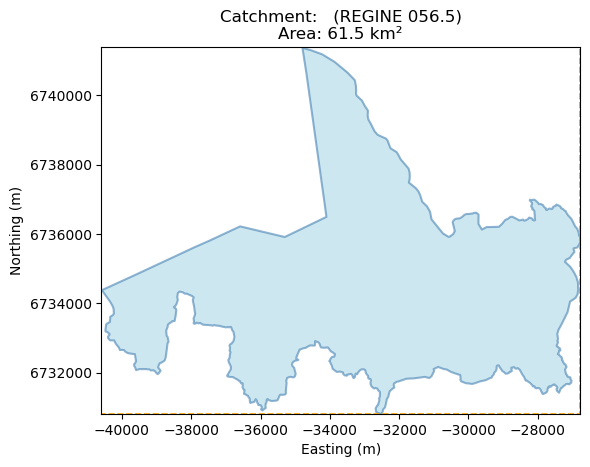

In [42]:

fig, ax = plt.subplots(figsize=(6, 6))
catchment_gdf.plot(ax=ax, facecolor="lightblue", edgecolor="steelblue",
                   linewidth=1.5, alpha=0.6)

# Draw bounding box
bbox_geom = gpd.GeoDataFrame(geometry=[box(*catchment_bbox)], crs=CRS)
bbox_geom.plot(ax=ax, facecolor="none", edgecolor="orange",
               linewidth=1.2, linestyle="--")

ax.set_title(f"Catchment: {name} (REGINE {reg_id})\nArea: {area_km2:.1f} km²")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
ax.set_aspect("equal")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()


In [43]:
catchment_path = OUTPUT_DIR / "catchment.geojson"
catchment_gdf.to_file(catchment_path, driver="GeoJSON")
print(f"Catchment boundary saved → {catchment_path}")

Catchment boundary saved → data/model_input/catchment.geojson


## Section 2 — Groundwater Wells and Springs

This section retrieves groundwater observation points from two open sources
and writes them to **two separate files** in `data/model_input/`:

| File | Contents |
|---|---|
| `wells_static.geojson / .csv` | All borehole and spring locations with a single watertable depth estimate (if available). Sources: GRANADA supply wells, springs, and LGN monitoring snapshot. |
| `wells_timeseries.geojson / .csv` | Monitoring-station locations with time-stamped or periodically measured water levels. Sources: NVE ArcGIS services and GRANADA LGN wells (snapshot + report link). |

### Sources

| Layer | Provider | API |
|---|---|---|
| Supply wells (`grunnvannbronn`) | NGU GRANADA | OGC API Features |
| Springs (`grunnvannoppkomme`) | NGU GRANADA | OGC API Features |
| LGN monitoring wells (`lgnbronn`) | NGU GRANADA | OGC API Features |
| Groundwater stations | NVE | ArcGIS FeatureServer |

> **GRANADA** (`grunnvannbronn`) contains ~81 000 supply boreholes.
> Most have no water-level field, but provide geological medium, drilled depth and
> yield — useful for constraining aquifer geometry.
> LGN wells (`lgnbronn`) are part of the national long-term monitoring network and
> carry a single water-table depth snapshot plus a link to the full report.


In [ ]:
# ─── GRANADA OGC API endpoints ────────────────────────────────────────────────
GRANADA_BASE        = "https://geo.ngu.no/api/features/grunnvannborehull/collections"
GRANADA_WELLS       = f"{GRANADA_BASE}/grunnvannbronn/items"        # supply wells (~81k)
GRANADA_SPRINGS     = f"{GRANADA_BASE}/grunnvannoppkomme/items"      # springs (~682)
GRANADA_LGN         = f"{GRANADA_BASE}/lgnbronn/items"              # LGN monitoring (~234)
GRANADA_LGN_SPRINGS = f"{GRANADA_BASE}/lgngrunnvannoppkomme/items"  # LGN springs (~19)

# ─── NVE ArcGIS groundwater monitoring endpoints ──────────────────────────────
NVE_GW_URLS = [
    "https://nve.geodataonline.no/arcgis/rest/services/HydrologiskeData3/MapServer/5/query",
    "https://nve.geodataonline.no/arcgis/rest/services/HydrologiskeData3/MapServer/17/query",
    "https://nve.geodataonline.no/arcgis/rest/services/HydrologiskeData3/MapServer/29/query",
]

# ─── Output paths ─────────────────────────────────────────────────────────────
STATIC_GEOJSON     = OUTPUT_DIR / "wells_static.geojson"
STATIC_CSV         = OUTPUT_DIR / "wells_static.csv"
TIMESERIES_GEOJSON = OUTPUT_DIR / "wells_timeseries.geojson"
TIMESERIES_CSV     = OUTPUT_DIR / "wells_timeseries.csv"

# ─── Request settings ─────────────────────────────────────────────────────────
_GW_TIMEOUT = 60
_GW_PAGE    = 500
_GW_CAP     = 20_000

In [ ]:


# ─── Shared fetch helpers ─────────────────────────────────────────────────────

def _to_wgs84_bbox(bbox_25833):
    """Convert a (xmin, ymin, xmax, ymax) bbox from EPSG:25833 to WGS-84."""
    t = Transformer.from_crs("EPSG:25833", "EPSG:4326", always_xy=True)
    lon0, lat0 = t.transform(bbox_25833[0], bbox_25833[1])
    lon1, lat1 = t.transform(bbox_25833[2], bbox_25833[3])
    return lon0, lat0, lon1, lat1


def _fetch_ogc_bbox(url, bbox_25833):
    """Page through an OGC API Features endpoint, filtering by bbox (WGS-84).
    Returns a GeoDataFrame in EPSG:25833, or None if nothing was found."""
    lon0, lat0, lon1, lat1 = _to_wgs84_bbox(bbox_25833)
    params = {
        "f":    "json",
        "bbox": f"{lon0},{lat0},{lon1},{lat1}",
        "limit": _GW_PAGE,
    }
    all_features, next_url = [], url
    while next_url:
        r = requests.get(
            next_url, params=params,
            headers={"Accept": "application/geo+json"},
            timeout=_GW_TIMEOUT,
        )
        r.raise_for_status()
        payload = r.json()
        all_features.extend(payload.get("features", []))
        next_url = next(
            (lnk["href"] for lnk in payload.get("links", []) if lnk.get("rel") == "next"),
            None,
        )
        params = None  # subsequent pages use full "next" URL
        if len(all_features) >= _GW_CAP:
            warnings.warn(f"Reached safety cap ({_GW_CAP} records) for {url}")
            break
    if not all_features:
        return None
    gdf = gpd.GeoDataFrame.from_features(all_features)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    return gdf.to_crs(CRS)


def _fetch_arcgis_bbox(url, bbox_25833):
    """Page through an ArcGIS FeatureServer/query endpoint with a bbox filter.
    Returns a GeoDataFrame in EPSG:25833, or None if nothing was found."""
    xmin, ymin, xmax, ymax = bbox_25833
    all_features, offset = [], 0
    while True:
        params = {
            "where":             "1=1",
            "f":                 "geojson",
            "outFields":         "*",
            "returnGeometry":    "true",
            "outSR":             25833,
            "resultRecordCount": _GW_PAGE,
            "resultOffset":      offset,
            "geometry":          f"{xmin},{ymin},{xmax},{ymax}",
            "geometryType":      "esriGeometryEnvelope",
            "inSR":              25833,
            "spatialRel":        "esriSpatialRelIntersects",
        }
        r = requests.get(url, params=params, timeout=_GW_TIMEOUT)
        r.raise_for_status()
        payload = r.json()
        if "error" in payload:
            raise ValueError(f"ArcGIS error at {url}: {payload['error']}")
        feats = payload.get("features", [])
        all_features.extend(feats)
        if len(feats) < _GW_PAGE:
            break
        offset += _GW_PAGE
        if offset >= _GW_CAP:
            warnings.warn(f"Reached safety cap ({_GW_CAP}) for {url}")
            break
    if not all_features:
        return None
    gdf = gpd.GeoDataFrame.from_features(all_features, crs=CRS)
    return gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()


def _clip_to_catchment(gdf):
    """Clip a GeoDataFrame to the catchment polygon; return None if empty."""
    if gdf is None or gdf.empty:
        return None
    clipped = gpd.clip(gdf, catchment_gdf)
    return clipped if not clipped.empty else None


def _col(row, *names, default=None):
    """Return the first non-None value from a list of column names."""
    for n in names:
        v = row.get(n)
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return v
    return default


def _granada_nr(row, fallback=""):
    """Extract the numeric GRANADA well number from the rapport-JSON / rapport-HTML link."""
    for field in ("rapport-JSON", "rapport-HTML"):
        ref = _col(row, field)
        href = ref.get("href", "") if isinstance(ref, dict) else (str(ref) if ref else "")
        m = re.search(r"[?&]nummer=(\d+)", href)
        if m:
            return m.group(1)
    return fallback


print("Section 1b configuration and helpers ready.")


Section 1b configuration and helpers ready.


In [45]:

# ─── Fetch GRANADA static observations ────────────────────────────────────────
# Three GRANADA collections are combined into one static table:
#   grunnvannbronn    – supply boreholes (borehole structure only, no head value)
#   grunnvannoppkomme – natural springs   (location only)
#   lgnbronn          – LGN monitoring wells (static water-table snapshot)

static_parts = []

# ─── 1. Supply wells (grunnvannbronn) ─────────────────────────────────────────
print("Fetching GRANADA supply wells (grunnvannbronn)...")
try:
    _raw = _clip_to_catchment(_fetch_ogc_bbox(GRANADA_WELLS, catchment_bbox))
    if _raw is not None:
        rows = []
        for idx, row in _raw.iterrows():
            report = _col(row, "rapport-JSON") or {}
            rows.append({
                "well_id":             _granada_nr(row, fallback=f"granada_well_{idx}"),
                "source":              "GRANADA/grunnvannbronn",
                "well_type":           "supply_well",
                "geol_medium":         str(_col(row, "geolMedium", default="")),
                "bore_date":           str(_col(row, "boreDato", default="")),
                "drilled_depth_m":     pd.to_numeric(_col(row, "boretLengde"), errors="coerce"),
                "capacity_lh":         pd.to_numeric(_col(row, "boretKapasitet"), errors="coerce"),
                "depth_to_water_m":    pd.to_numeric(_col(row, "vannstandBorehull"), errors="coerce"),
                "date_depth_measured": str(_col(row, "datoVannstandBorehull", default="")),
                "measurement_freq":    "",
                "report_url":          report.get("href", "") if isinstance(report, dict) else "",
                "geometry":            row.geometry,
            })
        _part = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
        static_parts.append(_part)
        print(f"  {len(_part)} supply wells inside catchment")
    else:
        print("  No supply wells found inside catchment")
except Exception as exc:
    print(f"  grunnvannbronn fetch failed: {exc}")

# ─── 2. Springs (grunnvannoppkomme) ───────────────────────────────────────────
print("Fetching GRANADA springs (grunnvannoppkomme)...")
try:
    _raw = _clip_to_catchment(_fetch_ogc_bbox(GRANADA_SPRINGS, catchment_bbox))
    if _raw is not None:
        rows = []
        for idx, row in _raw.iterrows():
            report = _col(row, "rapport-JSON") or {}
            rows.append({
                "well_id":             _granada_nr(row, fallback=f"granada_spring_{idx}"),
                "source":              "GRANADA/grunnvannoppkomme",
                "well_type":           "spring",
                "geol_medium":         str(_col(row, "geolMedium", default="")),
                "bore_date":           str(_col(row, "oppkomRegDato", default="")),
                "drilled_depth_m":     np.nan,
                "capacity_lh":         np.nan,
                "depth_to_water_m":    np.nan,
                "date_depth_measured": "",
                "measurement_freq":    "",
                "report_url":          report.get("href", "") if isinstance(report, dict) else "",
                "geometry":            row.geometry,
            })
        _part = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
        static_parts.append(_part)
        print(f"  {len(_part)} springs inside catchment")
    else:
        print("  No springs found inside catchment")
except Exception as exc:
    print(f"  grunnvannoppkomme fetch failed: {exc}")

# ─── 3. LGN monitoring wells — static snapshot ────────────────────────────────
print("Fetching GRANADA LGN monitoring wells (lgnbronn)...")
lgn_gdf = None   # kept for reuse in the timeseries cell
try:
    lgn_gdf = _clip_to_catchment(_fetch_ogc_bbox(GRANADA_LGN, catchment_bbox))
    if lgn_gdf is not None:
        rows = []
        for idx, row in lgn_gdf.iterrows():
            report = _col(row, "rapport-JSON") or {}
            rows.append({
                "well_id":             str(_col(row, "br\u00f8nnNr", default=f"lgn_{idx}")),
                "source":              "GRANADA/lgnbronn",
                "well_type":           "lgn_monitoring_well",
                "geol_medium":         str(_col(row, "geolMedium", default="")),
                "bore_date":           str(_col(row, "boreDato", default="")),
                "drilled_depth_m":     pd.to_numeric(_col(row, "boretLengde"), errors="coerce"),
                "capacity_lh":         pd.to_numeric(_col(row, "boretKapasitet"), errors="coerce"),
                "depth_to_water_m":    pd.to_numeric(_col(row, "vannstandBorehull"), errors="coerce"),
                "date_depth_measured": str(_col(row, "datoVannstandBorehull", default="")),
                "measurement_freq":    str(_col(row, "m\u00e5leFrekvens", default="")),
                "report_url":          report.get("href", "") if isinstance(report, dict) else "",
                "geometry":            row.geometry,
            })
        _part = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
        static_parts.append(_part)
        print(f"  {len(_part)} LGN wells inside catchment")
    else:
        print("  No LGN wells found inside catchment")
except Exception as exc:
    print(f"  lgnbronn fetch failed: {exc}")

# ─── Combine and save ─────────────────────────────────────────────────────────
if not static_parts:
    print("\nNo GRANADA data found in catchment. Static file will be empty.")
    wells_static = gpd.GeoDataFrame(
        columns=["well_id", "source", "well_type", "geol_medium", "bore_date",
                 "drilled_depth_m", "capacity_lh", "depth_to_water_m",
                 "date_depth_measured", "measurement_freq", "report_url", "geometry"],
        geometry="geometry", crs=CRS,
    )
else:
    wells_static = gpd.GeoDataFrame(
        pd.concat(static_parts, ignore_index=True), geometry="geometry", crs=CRS,
    )

wells_static.to_file(STATIC_GEOJSON, driver="GeoJSON")
wells_static.drop(columns="geometry").to_csv(STATIC_CSV, index=False)
print(f"\nStatic file: {len(wells_static)} features")
print(f"  By type: {wells_static.groupby('well_type').size().to_dict() if len(wells_static) else 'empty'}")
print(f"  With depth-to-water: {wells_static['depth_to_water_m'].notna().sum()}")
print(f"  Saved -> {STATIC_GEOJSON}")


Fetching GRANADA supply wells (grunnvannbronn)...
  64 supply wells inside catchment
Fetching GRANADA springs (grunnvannoppkomme)...
  No springs found inside catchment
Fetching GRANADA LGN monitoring wells (lgnbronn)...
  No LGN wells found inside catchment

Static file: 64 features
  By type: {'supply_well': 64}
  With depth-to-water: 19
  Saved -> data/model_input/wells_static.geojson


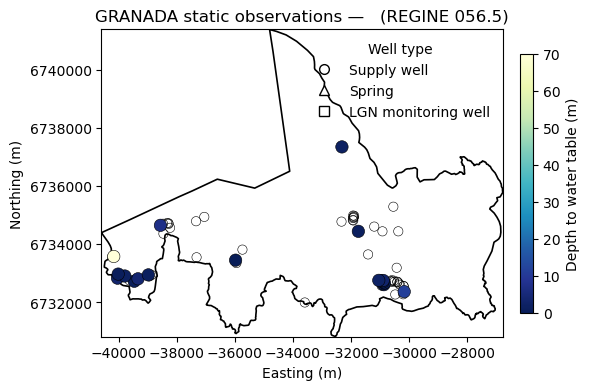

In [46]:
# ─── Plot: GRANADA static observations ───────────────────────────────────────
from matplotlib.lines import Line2D

_type_styles = {
    "supply_well":         {"marker": "o", "label": "Supply well"},
    "spring":              {"marker": "^", "label": "Spring"},
    "lgn_monitoring_well": {"marker": "s", "label": "LGN monitoring well"},
}

fig, ax = plt.subplots(figsize=(6, 6))
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2)

if not wells_static.empty:
    depth_vals = pd.to_numeric(wells_static["depth_to_water_m"], errors="coerce")
    has_depth = depth_vals.notna()

    # Plot wells without depth as hollow symbols.
    for wtype, style in _type_styles.items():
        subset = wells_static[(wells_static["well_type"] == wtype) & (~has_depth)]
        if subset.empty:
            continue
        ax.scatter(
            subset.geometry.x.values,
            subset.geometry.y.values,
            marker=style["marker"],
            s=45,
            facecolors="none",
            edgecolors="black",
            linewidths=0.4,
            zorder=4,
        )

    if has_depth.any():
        vmin = float(depth_vals[has_depth].min())
        vmax = float(depth_vals[has_depth].max())
        cmap = "YlGnBu_r"

        for wtype, style in _type_styles.items():
            subset = wells_static[(wells_static["well_type"] == wtype) & has_depth]
            if subset.empty:
                continue
            xs = subset.geometry.x.values
            ys = subset.geometry.y.values
            cs = pd.to_numeric(subset["depth_to_water_m"], errors="coerce").values
            ax.scatter(
                xs,
                ys,
                c=cs,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                marker=style["marker"],
                s=80,
                edgecolors="black",
                linewidths=0.4,
                zorder=4,
            )

        sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Depth to water table (m)", fraction=0.03, pad=0.04)

    handles = [
        Line2D([0], [0], marker=style["marker"], linestyle="", color="black",
               markerfacecolor="white", markeredgecolor="black", markersize=7,
               label=style["label"])
        for style in _type_styles.values()
    ]
    ax.legend(handles=handles, loc="upper right", frameon=False, title="Well type")

ax.set_title(f"GRANADA static observations — {name} (REGINE {reg_id})")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
ax.set_aspect("equal")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()


In [47]:

# ─── Fetch timeseries / monitoring observations ────────────────────────────────
# Sources (in order of preference):
#   1. NVE ArcGIS HydrologiskeData3 — time-stamped groundwater level stations
#   2. GRANADA lgnbronn              — long-term monitoring wells (snapshot +
#                                       link to full report for time-series download)
#
# NVE field detection is token-based because field names differ between layers.
# GRANADA LGN rows carry a 'report_url' column pointing to the per-well JSON
# report (visBronn.php?nummer=X&format=json) for offline time-series download.

_WL_TOKENS    = ["waterlevel", "water_level", "grunnvann", "gwlevel",
                  "grunnvannstand", "head", "nivaa", "elev", "elevation", "moh"]
_DEPTH_TOKENS = ["depthtowater", "depth_to_water", "watertable",
                  "dybdetilgrunnvann", "dybde_til_grunnvann"]
_TIME_TOKENS  = ["date", "dato", "time", "timestamp", "observed", "tidspunkt"]
_ID_TOKENS    = ["station", "stasjon", "well", "bore", "id", "objectid"]


def _token_col(df, tokens):
    """Return the first column whose normalised name contains any token."""
    def _norm(s):
        return "".join(c for c in str(s).lower() if c.isalnum() or c == "_")
    for col in df.columns:
        if col == "geometry":
            continue
        if any(t in _norm(col) for t in tokens):
            return col
    return None


def _best_numeric_col(df, tokens):
    """Among columns matching a token list, return the one with the most numeric values."""
    def _norm(s):
        return "".join(c for c in str(s).lower() if c.isalnum() or c == "_")
    best_col, best_n = None, 0
    for col in df.columns:
        if col == "geometry":
            continue
        if not any(t in _norm(col) for t in tokens):
            continue
        n = int(pd.to_numeric(df[col], errors="coerce").notna().sum())
        if n > best_n:
            best_col, best_n = col, n
    return best_col, best_n


timeseries_parts = []

# ─── 1. NVE ArcGIS monitoring stations ────────────────────────────────────────
for nve_url in NVE_GW_URLS:
    layer_id = nve_url.split("MapServer/")[1].split("/")[0]
    print(f"Trying NVE HydrologiskeData3 layer {layer_id}...")
    try:
        _raw = _clip_to_catchment(_fetch_arcgis_bbox(nve_url, catchment_bbox))
        if _raw is None:
            print("  No features inside catchment")
            continue

        id_col    = _token_col(_raw, _ID_TOKENS)
        time_col  = _token_col(_raw, _TIME_TOKENS)
        wl_col, _ = _best_numeric_col(_raw, _WL_TOKENS)
        dp_col, _ = _best_numeric_col(_raw, _DEPTH_TOKENS)

        part = pd.DataFrame()
        part["station_id"]        = (
            _raw[id_col].astype(str)
            if id_col else [f"nve_layer{layer_id}_{i}" for i in range(len(_raw))]
        )
        part["source"]            = f"NVE/HydrologiskeData3_layer{layer_id}"
        part["well_type"]         = "nve_monitoring_station"
        part["observation_time"]  = (
            pd.to_datetime(_raw[time_col], errors="coerce").dt.strftime("%Y-%m-%dT%H:%M:%S")
            if time_col else pd.NaT
        )
        part["water_level_masl"]  = (
            pd.to_numeric(_raw[wl_col], errors="coerce") if wl_col else np.nan
        )
        part["depth_to_water_m"] = (
            pd.to_numeric(_raw[dp_col], errors="coerce") if dp_col else np.nan
        )
        part["report_url"]        = ""
        part["geometry"]          = _raw.geometry.values

        _part = gpd.GeoDataFrame(part, geometry="geometry", crs=CRS)
        timeseries_parts.append(_part)
        print(f"  {len(_part)} stations  "
              f"| wl col: {wl_col}  | depth col: {dp_col}  | time col: {time_col}")
    except Exception as exc:
        print(f"  Endpoint unavailable: {exc}")

# ─── 2. GRANADA LGN monitoring wells ──────────────────────────────────────────
# lgn_gdf was fetched in the static cell above; reuse it here.
print("Adding GRANADA LGN wells to timeseries file...")
if lgn_gdf is not None and not lgn_gdf.empty:
    rows = []
    for idx, row in lgn_gdf.iterrows():
        report = _col(row, "rapport-JSON") or {}
        rows.append({
            "station_id":       str(_col(row, "br\u00f8nnNr", default=f"lgn_{idx}")),
            "source":           "GRANADA/lgnbronn",
            "well_type":        "lgn_monitoring_well",
            "observation_time": str(_col(row, "datoVannstandBorehull", default="")),
            "water_level_masl": np.nan,
            "depth_to_water_m": pd.to_numeric(_col(row, "vannstandBorehull"), errors="coerce"),
            "report_url":       report.get("href", "") if isinstance(report, dict) else "",
            "geometry":         row.geometry,
        })
    _part = gpd.GeoDataFrame(rows, geometry="geometry", crs=CRS)
    timeseries_parts.append(_part)
    print(f"  {len(_part)} LGN wells added (snapshot + report link)")
    print("  Tip: use 'report_url' with ?format=json to download per-well data.")
else:
    print("  No LGN wells in catchment (lgn_gdf is empty or not fetched)")

# ─── Combine and save ─────────────────────────────────────────────────────────
if not timeseries_parts:
    print("\nNo monitoring data found in catchment. Timeseries file will be empty.")
    wells_ts = gpd.GeoDataFrame(
        columns=["station_id", "source", "well_type", "observation_time",
                 "water_level_masl", "depth_to_water_m", "report_url", "geometry"],
        geometry="geometry", crs=CRS,
    )
else:
    wells_ts = gpd.GeoDataFrame(
        pd.concat(timeseries_parts, ignore_index=True), geometry="geometry", crs=CRS,
    )

wells_ts.to_file(TIMESERIES_GEOJSON, driver="GeoJSON")
wells_ts.drop(columns="geometry").to_csv(TIMESERIES_CSV, index=False)
print(f"\nTimeseries file: {len(wells_ts)} features")
print(f"  By source: {wells_ts.groupby('source').size().to_dict() if len(wells_ts) else 'empty'}")
print(f"  With water_level_masl : {wells_ts['water_level_masl'].notna().sum() if len(wells_ts) else 0}")
print(f"  With depth_to_water_m : {wells_ts['depth_to_water_m'].notna().sum() if len(wells_ts) else 0}")
print(f"  Saved -> {TIMESERIES_GEOJSON}")


Trying NVE HydrologiskeData3 layer 5...
  16 stations  | wl col: stasjonHoyde_moh  | depth col: None  | time col: dataFraDato
Trying NVE HydrologiskeData3 layer 17...
  16 stations  | wl col: stasjonHoyde_moh  | depth col: None  | time col: dataFraDato
Trying NVE HydrologiskeData3 layer 29...
  No features inside catchment
Adding GRANADA LGN wells to timeseries file...
  No LGN wells in catchment (lgn_gdf is empty or not fetched)

Timeseries file: 32 features
  By source: {'NVE/HydrologiskeData3_layer17': 16, 'NVE/HydrologiskeData3_layer5': 16}
  With water_level_masl : 32
  With depth_to_water_m : 0
  Saved -> data/model_input/wells_timeseries.geojson


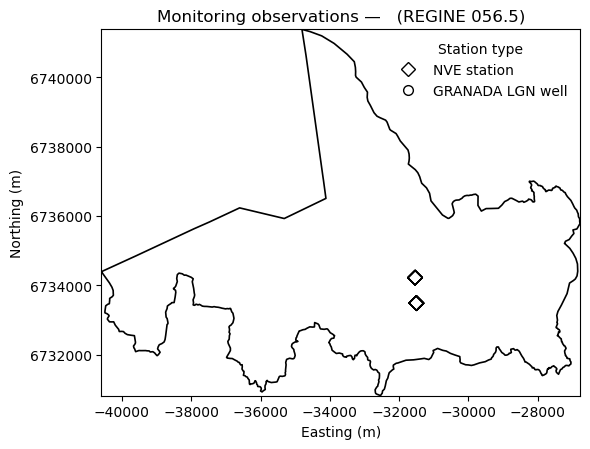

In [48]:
# ─── Plot: monitoring observations ────────────────────────────────────────────
from matplotlib.lines import Line2D

_ts_styles = {
    "nve_monitoring_station": {"marker": "D", "label": "NVE station"},
    "lgn_monitoring_well":    {"marker": "o", "label": "GRANADA LGN well"},
}

fig, ax = plt.subplots(figsize=(6, 6))
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2)

if not wells_ts.empty:
    depth_vals = pd.to_numeric(wells_ts["depth_to_water_m"], errors="coerce")
    has_depth = depth_vals.notna()

    if has_depth.any():
        vmin = float(depth_vals[has_depth].min())
        vmax = float(depth_vals[has_depth].max())
        cmap = "YlGnBu_r"

        for wtype, style in _ts_styles.items():
            subset = wells_ts[(wells_ts["well_type"] == wtype) & has_depth]
            if subset.empty:
                continue
            ax.scatter(
                subset.geometry.x.values,
                subset.geometry.y.values,
                c=pd.to_numeric(subset["depth_to_water_m"], errors="coerce").values,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                marker=style["marker"],
                s=55,
                edgecolors="black",
                linewidths=0.4,
                zorder=4,
            )

        sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Depth to water table (m)", fraction=0.03, pad=0.04)

    # Plot stations without depth as hollow symbols.
    for wtype, style in _ts_styles.items():
        subset = wells_ts[(wells_ts["well_type"] == wtype) & (~has_depth)]
        if subset.empty:
            continue
        ax.scatter(
            subset.geometry.x.values,
            subset.geometry.y.values,
            marker=style["marker"],
            s=55,
            facecolors="none",
            edgecolors="black",
            linewidths=0.9,
            zorder=4,
        )

    handles = [
        Line2D([0], [0], marker=style["marker"], linestyle="", color="black",
               markerfacecolor="white", markeredgecolor="black", markersize=7,
               label=style["label"])
        for style in _ts_styles.values()
    ]
    ax.legend(handles=handles, loc="upper right", frameon=False, title="Station type")

ax.set_title(f"Monitoring observations — {name} (REGINE {reg_id})")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
ax.set_aspect("equal")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()


## Section 2 — Digital Elevation Model (DEM)

The DEM comes from **[hoydedata.no](https://hoydedata.no)** — Kartverket's dedicated height
data portal, which exposes the national DTM (0.25 m native resolution) via an
ArcGIS ImageServer REST API. The service covers all of Norway and requires no authentication.

This step does two things:
1. Downloads a GeoTIFF for the catchment bounding box at the target resolution
2. Clips it to the catchment boundary, producing **`dem.tif`**

The raster transform and shape of `dem.tif` become the **master grid** that all subsequent
rasters (surface water, geology) are rasterized onto — this guarantees all three GeoTIFFs
have identical dimensions and can be stacked as FLOPY array inputs.


In [49]:
# ─── Set target resolution (metres) ──────────────────────────────────────────
# 100 m is a good compromise between runtime and realistic river representation
TARGET_RESOLUTION = 10   # metres

# Safety limit: refuse to fetch a raster larger than this many pixels
MAX_PIXELS = 50_000_000   # ~50 megapixels

bbox_width_m  = bounds[2] - bounds[0]
bbox_height_m = bounds[3] - bounds[1]
estimated_pixels = (bbox_width_m / TARGET_RESOLUTION) * (bbox_height_m / TARGET_RESOLUTION)

if estimated_pixels > MAX_PIXELS:
    old_res = TARGET_RESOLUTION
    TARGET_RESOLUTION = 200
    estimated_pixels = (bbox_width_m / TARGET_RESOLUTION) * (bbox_height_m / TARGET_RESOLUTION)
    print(f"  Auto-switched from {old_res} m → {TARGET_RESOLUTION} m resolution "
          f"(bounding box would be >{MAX_PIXELS/1e6:.0f} MP at {old_res} m).")
else:
    print(f"  Using {TARGET_RESOLUTION} m resolution "
          f"(estimated {estimated_pixels:.2f} pixels).")

  Using 10 m resolution (estimated 1459450.52 pixels).


In [50]:

# ─── Compute pixel dimensions ─────────────────────────────────────────────────
# The hoydedata.no ImageServer accepts explicit width × height in pixels.
# At TARGET_RESOLUTION metres per pixel, the required grid size is:
xmin, ymin, xmax, ymax = catchment_bbox
img_width  = max(1, min(15000, round((xmax - xmin) / TARGET_RESOLUTION)))
img_height = max(1, min(15000, round((ymax - ymin) / TARGET_RESOLUTION)))

print(f"Fetching DTM from hoydedata.no  ({TARGET_RESOLUTION} m, {img_width}×{img_height} px) ...")

params = {
    "bbox":      f"{xmin},{ymin},{xmax},{ymax}",
    "bboxSR":    25833,
    "size":      f"{img_width},{img_height}",
    "imageSR":   25833,
    "format":    "tiff",
    "pixelType": "F32",
    "noData":    -9999,
    "f":         "image",
}
r_dem = requests.get(HOYDEDATA_DTM_URL, params=params, timeout=300)
r_dem.raise_for_status()

# Validate that the response is a GeoTIFF (TIFF magic bytes)
tiff_magic = (b"II*\x00", b"MM\x00*", b"II+\x00", b"MM\x00+")
if r_dem.content[:4] not in tiff_magic:
    raise RuntimeError(
        f"hoydedata.no did not return a GeoTIFF (got {len(r_dem.content)} bytes).\n"
        f"Server response: {r_dem.text[:400]}"
    )

raw_dem_path = OUTPUT_DIR / "dem_raw.tif"
with open(raw_dem_path, "wb") as f:
    f.write(r_dem.content)
print(f"  Raw DEM saved    → {raw_dem_path}  ({len(r_dem.content)/1024:.0f} KB)")

# ─── Clip to catchment polygon (crop=True snaps to pixel-aligned grid) ────────
catchment_geom = [mapping(catchment_gdf.geometry.values[0])]

with rasterio.open(raw_dem_path) as src:
    dem_array, dem_transform = rasterio.mask.mask(
        src, catchment_geom, crop=True, nodata=np.nan, filled=True
    )
    dem_profile = src.profile.copy()

# Replace any remaining -9999 nodata values with NaN
dem_array = dem_array.astype("float32")
dem_array[dem_array == -9999] = np.nan

dem_profile.update({
    "driver":    "GTiff",
    "dtype":     "float32",
    "height":    dem_array.shape[1],
    "width":     dem_array.shape[2],
    "transform": dem_transform,
    "crs":       CRS,
    "nodata":    np.nan,
    "compress":  "lzw",
    "count":     1,
})

dem_path = OUTPUT_DIR / "dem.tif"
with rasterio.open(dem_path, "w", **dem_profile) as dst:
    dst.write(dem_array[0], 1)

# ─── Store the master grid — all other rasters will use this ─────────────────
master_transform = dem_transform
master_shape     = (dem_profile["height"], dem_profile["width"])   # (nrows, ncols)
master_crs       = CRS

print(f"  DEM clipped      → {dem_path}")
print(f"\n  Master grid : {master_shape[0]} rows × {master_shape[1]} cols")
print(f"  Resolution  : {TARGET_RESOLUTION} m")
print(f"  CRS         : {master_crs}")


Fetching DTM from hoydedata.no  (10 m, 1381×1057 px) ...
  Raw DEM saved    → data/model_input/dem_raw.tif  (6338 KB)
  DEM clipped      → data/model_input/dem.tif

  Master grid : 1057 rows × 1381 cols
  Resolution  : 10 m
  CRS         : EPSG:25833


In [51]:

with rasterio.open(dem_path) as src:
    elevation = src.read(1).astype(float)
    elevation[elevation == src.nodata] = np.nan

# Simple hillshade from gradient
gy, gx   = np.gradient(elevation, TARGET_RESOLUTION)
slope    = np.sqrt(gx**2 + gy**2)
azimuth  = np.radians(315)
altitude = np.radians(45)
hillshade = (
    np.cos(altitude) * np.cos(np.arctan(slope))
    + np.sin(altitude) * np.sin(np.arctan(slope))
    * np.cos(azimuth - np.arctan2(-gy, gx))
)
hillshade = np.clip(hillshade, 0, 1)


print(f"  Grid size  : {master_shape[0]} rows × {master_shape[1]} cols")
print(f"  Elevation  : min={np.nanmin(elevation):.1f} m, "
      f"max={np.nanmax(elevation):.1f} m, "
      f"mean={np.nanmean(elevation):.1f} m")


  Grid size  : 1057 rows × 1381 cols
  Elevation  : min=-5.7 m, max=672.8 m, mean=168.5 m


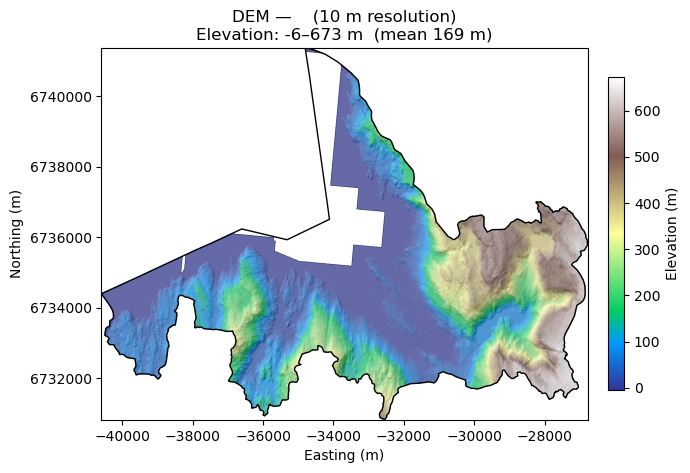

In [52]:
# ─── Plot: DEM ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(elevation, cmap="terrain", extent=extent)
ax.imshow(hillshade, cmap="gray", alpha=0.4, extent=extent)
#_plot_sea_polygon(ax, alpha=0.30)
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.03, pad=0.04)
ax.set_title(
    f"DEM — {name}  ({TARGET_RESOLUTION} m resolution)\n"
    f"Elevation: {np.nanmin(elevation):.0f}–{np.nanmax(elevation):.0f} m  "
    f"(mean {np.nanmean(elevation):.0f} m)"
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()


## Section 3 — Sea Boundary

This section marks each model cell as either land or sea:

| Value | Meaning |
|---|---|
| **0** | Land (default) |
| **1** | Sea (open water, fjord, ocean) |

**Data source**: OpenStreetMap [`natural=coastline`](https://wiki.openstreetmap.org/wiki/Tag:natural%3Dcoastline)
ways, fetched via the [Overpass API](https://overpass-api.de). OSM coastlines in Norway are
digitised at high detail and include fjord entrances.

The coastline ways are assembled into a continuous line, then combined with the bounding-box
boundary to produce a closed sea polygon. The catchment centroid (always on land) is used to
identify which polygon is the land polygon; the sea polygon is the remainder.

> **Inland catchments**: If no coastline is found within the search area (no coast within 10 km
> of the catchment bounding box), an all-zero `sea.tif` is saved silently and this section
> prints a short notice.

In [53]:

# ─── Build a 10 km search bbox around the catchment in WGS84 ─────────────────
_expand = 10_000   # metres
_to_wgs84_sea = Transformer.from_crs("EPSG:25833", "EPSG:4326", always_xy=True)

minx, miny, maxx, maxy = catchment_gdf.total_bounds          # EPSG:25833
minx -= _expand; miny -= _expand; maxx += _expand; maxy += _expand

sw_lon, sw_lat = _to_wgs84_sea.transform(minx, miny)
ne_lon, ne_lat = _to_wgs84_sea.transform(maxx, maxy)
# Overpass uses (south,west,north,east)
_bb = f"{sw_lat:.5f},{sw_lon:.5f},{ne_lat:.5f},{ne_lon:.5f}"

overpass_query = f"""
[out:json][timeout:60];
(
  way["natural"="coastline"]({_bb});
);
out geom;
"""

print("Querying OSM Overpass for coastline ways …")
print(f"  Search bbox (WGS84): S={sw_lat:.4f} W={sw_lon:.4f} N={ne_lat:.4f} E={ne_lon:.4f}")

_overpass_mirrors = [
    OSM_OVERPASS_URL,
    "https://overpass.kumi.systems/api/interpreter",
    "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
]
_ways = []
for _mirror in _overpass_mirrors:
    try:
        _resp = requests.post(_mirror, data={"data": overpass_query}, timeout=90)
        _resp.raise_for_status()
        _ways = _resp.json().get("elements", [])
        print(f"  {len(_ways)} coastline way(s) returned (via {_mirror})")
        break
    except Exception as _e:
        print(f"  {_mirror} failed: {_e}")

if not _ways:
    print("  All Overpass mirrors failed — treating catchment as inland.")

# ─── Assemble coastline into sea/land polygons ────────────────────────────────
sea_poly_25833 = None   # will remain None for inland catchments

if _ways:
    from shapely.geometry import LineString as SLS

    # Collect individual line segments from each OSM way
    _lines = []
    for _w in _ways:
        coords_wgs = [(nd["lon"], nd["lat"]) for nd in _w.get("geometry", []) if "lon" in nd]
        if len(coords_wgs) >= 2:
            _lines.append(SLS(coords_wgs))

    if _lines:
        # Merge collinear/touching segments and polygonize with the bbox ring
        _merged   = linemerge(_lines)
        _bbox_box = box(sw_lon, sw_lat, ne_lon, ne_lat)
        _all_segs = unary_union([_merged, _bbox_box.boundary])
        _polys    = list(polygonize(_all_segs))

        if not _polys:
            print("  polygonize returned 0 polygons — coastline may not intersect the bbox.")
        else:
            # Use the DEM peak (highest elevation cell) as the land reference point.
            # The catchment centroid can fall over a fjord, which causes the wrong
            # polygon to be identified as land. The mountain top is always on land.
            from rasterio.transform import xy as _ra_xy
            _dem_nd = dem_profile.get("nodata", None)
            _dem_f  = np.where(
                (dem_array == _dem_nd) if _dem_nd is not None else np.zeros_like(dem_array, dtype=bool),
                np.nan, dem_array.astype(float)
            )
            _peak_rc = np.unravel_index(np.nanargmax(_dem_f), _dem_f.shape)
            _px_25833, _py_25833 = _ra_xy(master_transform, _peak_rc[0], _peak_rc[1])
            _to_wgs84_land = Transformer.from_crs("EPSG:25833", "EPSG:4326", always_xy=True)
            _px_wgs, _py_wgs = _to_wgs84_land.transform(_px_25833, _py_25833)
            from shapely.geometry import Point as SP
            _land_pt   = SP(_px_wgs, _py_wgs)
            print(f"  Land reference point (DEM peak): ({_px_wgs:.4f}°E, {_py_wgs:.4f}°N)")

            _land_polys = [p for p in _polys if p.contains(_land_pt)]

            if not _land_polys:
                # Fallback: largest polygon is land
                print("  Land point not inside any polygon — falling back to largest polygon.")
                _land_polys = [max(_polys, key=lambda p: p.area)]

            _land_union = unary_union(_land_polys)

            # Sea = bbox in EPSG:25833 minus the land polygon
            _gdf_land_wgs = gpd.GeoDataFrame(geometry=[_land_union], crs="EPSG:4326")
            _gdf_land_utm = _gdf_land_wgs.to_crs("EPSG:25833")
            _land_poly_utm = _gdf_land_utm.geometry.iloc[0]
            _bbox_25833    = box(minx, miny, maxx, maxy)
            sea_poly_25833 = _bbox_25833.difference(_land_poly_utm)
            print(f"  Sea polygon area: {sea_poly_25833.area / 1e6:.1f} km²")
    else:
        print("  No valid line segments — treating catchment as inland.")


Querying OSM Overpass for coastline ways …
  Search bbox (WGS84): S=60.2483 W=5.0285 N=60.5633 E=5.5520
  https://overpass-api.de/api/interpreter failed: 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter
  2338 coastline way(s) returned (via https://overpass.kumi.systems/api/interpreter)
  Land reference point (DEM peak): (5.3245°E, 60.4564°N)
  Sea polygon area: 650.0 km²


In [54]:
# ─── Rasterize sea mask onto the master grid ─────────────────────────────────
## 0 = land, 1 = sea
sea_array = np.zeros(master_shape, dtype=np.int16)

if sea_poly_25833 is not None and not sea_poly_25833.is_empty:
    rasterio.features.rasterize(
        shapes=[(mapping(sea_poly_25833), 1)],
        out=sea_array,
        transform=master_transform,
        fill=0,
        merge_alg=rasterio.enums.MergeAlg.replace,
        dtype=np.int16,
    )

# Keep a GeoDataFrame copy for easy overlay on all subsequent maps.
if sea_poly_25833 is not None and not sea_poly_25833.is_empty:
    sea_poly_plot_gdf = gpd.GeoDataFrame(geometry=[sea_poly_25833], crs=CRS)
else:
    sea_poly_plot_gdf = gpd.GeoDataFrame(geometry=[], crs=CRS)


def _plot_sea_polygon(ax, facecolor="#4472C4", alpha=0.35, edgecolor="none", zorder=3):
    if "sea_poly_plot_gdf" in globals() and len(sea_poly_plot_gdf) > 0:
        sea_poly_plot_gdf.plot(
            ax=ax,
            color=facecolor,
            alpha=alpha,
            edgecolor=edgecolor,
            linewidth=0.0,
            zorder=zorder,
        )


# ─── Save raster ──────────────────────────────────────────────────────────────
sea_profile = {
    "driver":    "GTiff",
    "dtype":     "int16",
    "height":    master_shape[0],
    "width":     master_shape[1],
    "count":     1,
    "crs":       master_crs,
    "transform": master_transform,
    "nodata":    -1,
    "compress":  "lzw",
}
sea_path = OUTPUT_DIR / "sea.tif"
with rasterio.open(sea_path, "w", **sea_profile) as dst:
    dst.write(sea_array, 1)

# Also enforce sea-level topography in DEM so marine cells are 0 m.
sea_cells = sea_array == 1
n_filled = int(np.sum(sea_cells))
if n_filled > 0:
    with rasterio.open(dem_path) as src:
        dem_data = src.read(1).astype("float32")
        dem_meta = src.profile.copy()
    dem_data[sea_cells] = 0.0
    with rasterio.open(dem_path, "w", **dem_meta) as dst:
        dst.write(dem_data, 1)
    if "elevation" in globals():
        elevation[sea_cells] = 0.0

n_sea = int(np.sum(sea_array == 1))
n_land = int(np.sum(sea_array == 0))
print(f"Sea mask saved → {sea_path}")
print(f"  Sea cells  : {n_sea:,}  (value 1)")
print(f"  Land cells : {n_land:,}  (value 0)")
print(f"  DEM sea cells set to 0 m: {n_filled:,}")
if n_sea == 0:
    print("  (no coast found — all-zero raster saved)")

Sea mask saved → data/model_input/sea.tif
  Sea cells  : 545,861  (value 1)
  Land cells : 913,856  (value 0)
  DEM sea cells set to 0 m: 545,861


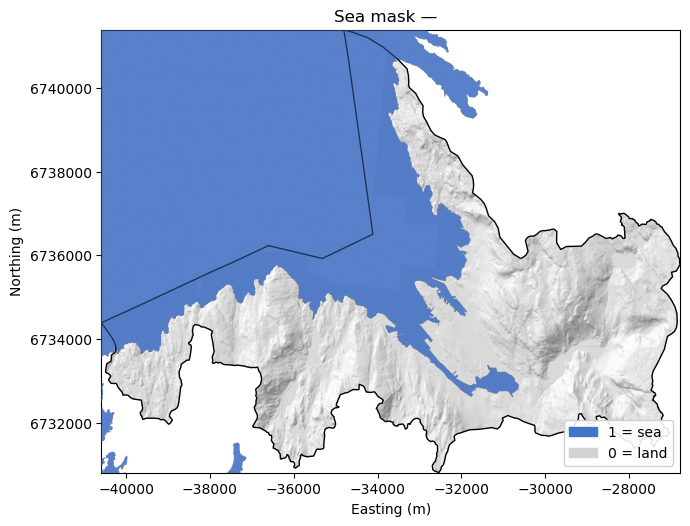

In [55]:
cmap_sea = mcolors.ListedColormap(["#4472C4"])
norm_sea = mcolors.BoundaryNorm([0.5, 1.5], cmap_sea.N)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(hillshade, cmap="gray", alpha=0.5, extent=extent)
_plot_sea_polygon(ax, facecolor="#4472C4", alpha=0.45)
ax.imshow(
    np.where(sea_array == 1, 1.0, np.nan),
    cmap=cmap_sea, norm=norm_sea, alpha=0.8, extent=extent,
 )
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1)

patches_sea = [
    mpatches.Patch(color="#4472C4", label="1 = sea"),
    mpatches.Patch(color="lightgray", label="0 = land"),
]
ax.legend(handles=patches_sea, loc="lower right", framealpha=0.9)
ax.set_title(f"Sea mask — {name}")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()

## Section 4 — Surface Water Bodies

In this section we prepare `surface_water.tif` from NVE open datasets and the sea mask.
The goal is to create a simple and robust raster mask for groundwater boundary conditions.

| NVE service | Layer | Contents |
|---|---|---|
| `Innsjodatabase2` | layer 5 — *Innsjødatabase* | Lake polygons |
| `Elvenett1` | layer 2 — *elvenett* | River network (LineStrings) |

**Encoding of `surface_water.tif`:**

| Value | Meaning | Typical MODFLOW package |
|---|---|---|
| 0 | No surface water | — (interior cells) |
| 1 | Lake | Lake, GHB, or CHD package |
| 2 | River | RIV or SFR package |
| 3 | Sea | CHD (fixed head at sea level) |

### How rivers are rasterized

NVE Elvenett contains very dense headwater networks. On coarse grids, including all
streams can overestimate river-covered area. We therefore use a transparent, two-step approach:
1. Keep rivers with Strahler order >= 2 (configurable).
2. Rasterize with conservative one-cell continuity bridging.

This keeps the river mask hydrologically meaningful at catchment scale while still being
easy to explain and reproduce in a teaching notebook.

In [56]:

def _fetch_nve_layer(url, bbox, timeout=120):
    """Fetch all features from an NVE ArcGIS REST FeatureLayer within a bounding box.

    Handles ArcGIS pagination via resultOffset / exceededTransferLimit.
    Returns a GeoDataFrame (EPSG:25833), or None if no features are found.
    """
    xmin, ymin, xmax, ymax = bbox
    base_params = {
        "geometry":          f"{xmin},{ymin},{xmax},{ymax}",
        "geometryType":      "esriGeometryEnvelope",
        "inSR":              25833,
        "spatialRel":        "esriSpatialRelIntersects",
        "outFields":         "*",
        "outSR":             25833,
        "f":                 "geojson",
        "resultRecordCount": 1000,
    }
    all_features = []
    offset = 0
    while True:
        params = {**base_params, "resultOffset": offset}
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        if "error" in data:
            raise ValueError(f"NVE API error {data['error'].get('code','?')}: "
                             f"{data['error'].get('message', str(data['error']))}")
        feats = data.get("features", [])
        all_features.extend(feats)
        if not data.get("exceededTransferLimit", False):
            break
        offset += len(feats)

    if not all_features:
        return None
    return gpd.GeoDataFrame.from_features(all_features, crs=CRS)


# ─── Fetch lakes (NVE Innsjødatabase — polygon layer) ─────────────────────────
print("Fetching lakes from NVE Innsjødatabase ...")
lakes_raw = _fetch_nve_layer(NVE_LAKES_URL, catchment_bbox)
if lakes_raw is not None:
    lakes_gdf = gpd.clip(lakes_raw.to_crs(CRS), catchment_gdf)
    lakes_gdf = lakes_gdf[~lakes_gdf.geometry.is_empty].reset_index(drop=True)
    print(f"  {len(lakes_gdf)} lake polygon(s) clipped to catchment")
else:
    lakes_gdf = None
    print("  No lakes found in this catchment.")

# ─── Fetch rivers (NVE Elvenett — LineString layer) ───────────────────────────
print("\nFetching rivers from NVE Elvenett ...")
rivers_raw = _fetch_nve_layer(NVE_RIVERS_URL, catchment_bbox)
if rivers_raw is not None:
    rivers_gdf = gpd.clip(rivers_raw.to_crs(CRS), catchment_gdf)
    rivers_gdf = rivers_gdf[~rivers_gdf.geometry.is_empty].reset_index(drop=True)
    print(f"  {len(rivers_gdf)} river feature(s) clipped to catchment")
else:
    rivers_gdf = None
    print("  No rivers found in this catchment.")


Fetching lakes from NVE Innsjødatabase ...
  32 lake polygon(s) clipped to catchment

Fetching rivers from NVE Elvenett ...
  114 river feature(s) clipped to catchment


In [57]:
# ─── Prepare rivers for rasterization ─────────────────────────────────────────
# Elvenett contains many small first-order streams. To avoid overfilling coarse grids,
# we filter by Strahler order and keep order >= 2 by default.
MIN_STRAHLER_ORDER = 2

# Optional geometric buffer in metres (0 means no explicit widening)
RIVER_BUFFER_M = 0.0

if rivers_gdf is not None and len(rivers_gdf) > 0:
    if "elveordenStrahler" in rivers_gdf.columns:
        n_before = len(rivers_gdf)
        rivers_gdf = rivers_gdf[rivers_gdf["elveordenStrahler"].fillna(0) >= MIN_STRAHLER_ORDER].copy()
        rivers_gdf = rivers_gdf.reset_index(drop=True)
        print(f"Filtered rivers by Strahler order >= {MIN_STRAHLER_ORDER}: {n_before} -> {len(rivers_gdf)} features")
    else:
        print("Warning: 'elveordenStrahler' field not found; using all river features.")

    rivers_buffered = rivers_gdf.copy()
    if RIVER_BUFFER_M > 0.0:
        rivers_buffered["geometry"] = rivers_gdf.geometry.buffer(RIVER_BUFFER_M)
        print(f"Applied river buffer: {RIVER_BUFFER_M:.1f} m")
    else:
        print("No explicit river buffer applied.")
else:
    rivers_buffered = None
    print("No rivers available after filtering.")


def bridge_one_cell_gaps(binary_mask):
    """
    Fill 1-cell gaps between river pixels to improve continuity.

    This operation is intentionally conservative: it only fills a cell when it sits
    between two already-river cells in horizontal, vertical, or diagonal directions.
    """
    m = binary_mask.astype(bool)
    p = np.pad(m, 1, mode="constant", constant_values=False)

    c  = p[1:-1, 1:-1]
    l  = p[1:-1, :-2]
    r  = p[1:-1, 2:]
    u  = p[:-2, 1:-1]
    d  = p[2:, 1:-1]
    ul = p[:-2, :-2]
    ur = p[:-2, 2:]
    dl = p[2:, :-2]
    dr = p[2:, 2:]

    bridge = (~c) & ((l & r) | (u & d) | (ul & dr) | (ur & dl))
    return m | bridge

Filtered rivers by Strahler order >= 2: 114 -> 35 features
No explicit river buffer applied.


In [58]:
# ─── Rasterize onto the master grid ──────────────────────────────────────────
# Burn rivers (2) first, then lakes (1) on top — lakes take priority.
# Sea cells are added afterward as value 3.
sw_array = np.zeros(master_shape, dtype=np.int16)

if rivers_buffered is not None and len(rivers_buffered) > 0:
    river_shapes = [
        (geom, 2)
        for geom in rivers_buffered.geometry
        if geom is not None and not geom.is_empty
    ]

    rasterio.features.rasterize(
        shapes=river_shapes,
        out=sw_array,
        transform=master_transform,
        fill=0,
        all_touched=True,
        dtype=np.int16,
    )

    # Improve continuity by bridging one-cell gaps in the river raster
    river_mask = sw_array == 2
    river_mask = bridge_one_cell_gaps(river_mask)
    sw_array[river_mask] = 2

if lakes_gdf is not None and len(lakes_gdf) > 0:
    lake_shapes = [
        (geom, 1)
        for geom in lakes_gdf.geometry
        if geom is not None and not geom.is_empty
    ]
    # Lakes override any river pixels that fall inside a lake polygon
    rasterio.features.rasterize(
        shapes=lake_shapes,
        out=sw_array,
        transform=master_transform,
        fill=0,
        dtype=np.int16,
        merge_alg=rasterio.enums.MergeAlg.replace,
    )

# Overlay sea as class 3.
if "sea_array" in globals():
    sw_array[sea_array == 1] = 3

# ─── Save raster with same spatial profile as dem.tif ────────────────────────
sw_profile = {
    "driver":    "GTiff",
    "dtype":     "int16",
    "height":    master_shape[0],
    "width":     master_shape[1],
    "count":     1,
    "crs":       master_crs,
    "transform": master_transform,
    "nodata":    -1,
    "compress":  "lzw",
}
sw_path = OUTPUT_DIR / "surface_water.tif"
with rasterio.open(sw_path, "w", **sw_profile) as dst:
    dst.write(sw_array, 1)

valid_mask = np.isfinite(elevation)
n_valid = int(np.sum(valid_mask))
n_lake = int(np.sum((sw_array == 1) & valid_mask))
n_river = int(np.sum((sw_array == 2) & valid_mask))
n_sea = int(np.sum((sw_array == 3) & valid_mask))

print(f"Surface water raster saved → {sw_path}")
print(f"  Pixel counts:  0 (no water) = {np.sum(sw_array == 0):,}")
print(f"                 1 (lake)     = {np.sum(sw_array == 1):,}")
print(f"                 2 (river)    = {np.sum(sw_array == 2):,}")
print(f"                 3 (sea)      = {np.sum(sw_array == 3):,}")
if n_valid > 0:
    print(
        f"  Coverage in active DEM cells: "
        f"lake={100.0*n_lake/n_valid:.2f}%, "
        f"river={100.0*n_river/n_valid:.2f}%, "
        f"sea={100.0*n_sea/n_valid:.2f}%"
    )

Surface water raster saved → data/model_input/surface_water.tif
  Pixel counts:  0 (no water) = 894,733
                 1 (lake)     = 17,963
                 2 (river)    = 1,160
                 3 (sea)      = 545,861
  Coverage in active DEM cells: lake=1.80%, river=0.12%, sea=54.74%


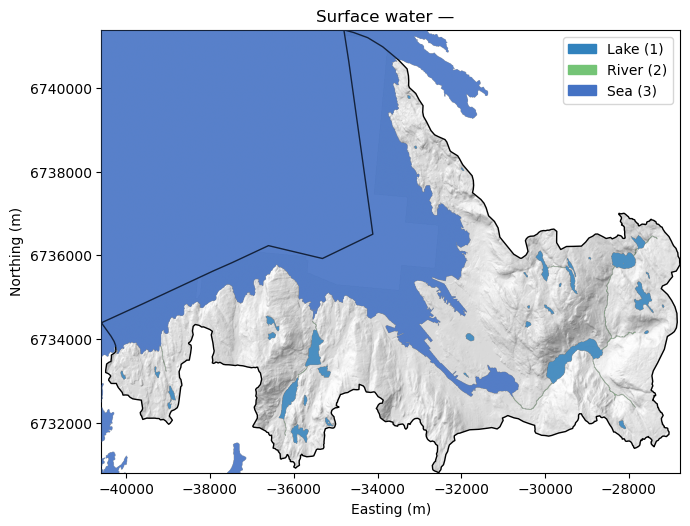

In [59]:
cmap_sw  = mcolors.ListedColormap(["#f0f0f0", "#3182bd", "#74c476", "#4472C4"])
bounds_sw = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_sw  = mcolors.BoundaryNorm(bounds_sw, cmap_sw.N)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(hillshade, cmap="gray", alpha=0.5, extent=extent)
_plot_sea_polygon(ax, alpha=0.30)
ax.imshow(
    np.where(sw_array > 0, sw_array.astype(float), np.nan),
    cmap=cmap_sw, norm=norm_sw, alpha=0.85, extent=extent,
 )
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1)

patches_sw = [
    mpatches.Patch(color="#3182bd", label="Lake (1)"),
    mpatches.Patch(color="#74c476", label="River (2)"),
    mpatches.Patch(color="#4472C4", label="Sea (3)"),
]
ax.legend(handles=patches_sw)
ax.set_title(f"Surface water — {name}")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()

## Section 5 — Quaternary Geology (Loose Deposits)

Loose deposit polygons are fetched from **NGU's (Norges geologiske undersøkelse)
Løsmasse Regionalt** dataset via the **NGU OGC API Features** service.
Each polygon is assigned an **integer ID** (1 … N) based on its deposit type
(`løsmassetypeNavn`). The mapping — including **groundwater potential** and
**infiltration potential** — is saved in `geology_legend.csv`.

> **Why loose deposits rather than bedrock?** For most groundwater models the
> hydraulic conductivity is controlled by the unconsolidated sediments (glacial
> till, sand, gravel, lake/marine deposits) above bedrock, not by the rock itself.
> The `grunnvannPotensialNavn` column can be used directly to prioritise high-K
> zones when assigning hydraulic conductivity values.

The integer IDs in `geology.tif` correspond directly to rows in `geology_legend.csv`:

```python
# Example use in your FLOPY modelling notebook:
import pandas as pd
legend   = pd.read_csv("data/model_input/geology_legend.csv", index_col="id")
# High groundwater potential → higher K
K_lookup = {row_id: 1e-4 if "Stor" in str(row["gw_potential"]) else 1e-6
            for row_id, row in legend.iterrows()}
```


In [60]:

# ─── Convert catchment bbox to WGS84 for OGC API bbox parameter ──────────────
_to_wgs84 = Transformer.from_crs("EPSG:25833", "EPSG:4326", always_xy=True)
lon_min, lat_min = _to_wgs84.transform(catchment_bbox[0], catchment_bbox[1])
lon_max, lat_max = _to_wgs84.transform(catchment_bbox[2], catchment_bbox[3])
bbox_wgs84 = f"{lon_min},{lat_min},{lon_max},{lat_max}"

# Define the CRS we want geometries delivered in (EPSG:25833)
_CRS_URI = "http://www.opengis.net/def/crs/EPSG/0/25833"

# ─── Fetch all loose-deposit polygons (with pagination) ──────────────────────
print("Fetching loose-deposit polygons from NGU OGC API Features ...")
all_features = []
next_url = NGU_LOSM_URL
params = {
    "f":        "json",
    "bbox":     bbox_wgs84,
    "crs":      _CRS_URI,
    "limit":    1000,
}

while next_url:
    r = requests.get(next_url, params=params, headers={"Accept": "application/geo+json"}, timeout=120)
    r.raise_for_status()
    data = r.json()
    feats = data.get("features", [])
    all_features.extend(feats)
    print(f"  fetched {len(all_features)} / {data.get('numberMatched', '?')} features ...")
    # Follow 'next' link for next page; clear params (they're already in the link)
    links = data.get("links", [])
    next_url = next((l["href"] for l in links if l.get("rel") == "next"), None)
    params = None   # next link already contains all query parameters

if not all_features:
    raise ValueError(
        "No loose-deposit features returned from NGU for this catchment.\n"
        f"Bbox (WGS84): {bbox_wgs84}\n"
        "Try a different catchment, or check data coverage at https://geo.ngu.no"
    )

geology_gdf = gpd.GeoDataFrame.from_features(all_features, crs=CRS)
geology_gdf = gpd.clip(geology_gdf.to_crs(CRS), catchment_gdf)
geology_gdf = geology_gdf[~geology_gdf.geometry.is_empty].reset_index(drop=True)

print(f"\n  {len(geology_gdf)} polygon(s) clipped to catchment")
print(f"  Columns: {list(geology_gdf.columns)}")


Fetching loose-deposit polygons from NGU OGC API Features ...
  fetched 72 / 72 features ...

  25 polygon(s) clipped to catchment
  Columns: ['geometry', 'objtype', 'datauttaksdato', 'oppdateringsdato', 'medium', 'mediumNavn', 'identifikasjon.lokalId', 'identifikasjon.navnerom', 'identifikasjon.versjonId', 'løsmassetype', 'løsmassetypeNavn', 'løsmassetypeBesk', 'infiltrasjonPotensial', 'infiltrasjonPotensialNavn', 'infiltrasjonPotensialBesk', 'grunnvannPotensial', 'grunnvannPotensialNavn', 'grunnvannPotensialBesk', 'egnetMålestokk', 'geolTemajustering']


In [61]:

# ─── Inspect attributes ───────────────────────────────────────────────────────
print("Sample loose-deposit attributes (first 5 rows):")
disp_cols = [c for c in geology_gdf.columns if c != "geometry"]
print(geology_gdf[disp_cols].head(5).to_string(index=False))

# The type column is always 'løsmassetypeNavn' in this dataset
ROCK_TYPE_COL = "løsmassetypeNavn"
if ROCK_TYPE_COL not in geology_gdf.columns:
    # Fallback: first non-geometry column
    ROCK_TYPE_COL = disp_cols[0]
    print(f"\n  Warning: expected column not found — using '{ROCK_TYPE_COL}'.")

print(f"\n  Deposit-type column: '{ROCK_TYPE_COL}'")

# ─── Assign integer IDs 1…N to each unique deposit type ──────────────────────
unique_types = sorted(geology_gdf[ROCK_TYPE_COL].dropna().unique())
rock_to_id   = {rtype: i + 1 for i, rtype in enumerate(unique_types)}
geology_gdf["rock_id"] = geology_gdf[ROCK_TYPE_COL].map(rock_to_id).fillna(0).astype(int)

# ─── Build legend DataFrame (include groundwater and infiltration potential) ──
gw_col   = "grunnvannPotensialNavn"   if "grunnvannPotensialNavn"   in geology_gdf.columns else None
inf_col  = "infiltrasjonPotensialNavn" if "infiltrasjonPotensialNavn" in geology_gdf.columns else None

legend_rows = []
for rtype, rid in rock_to_id.items():
    mask = geology_gdf[ROCK_TYPE_COL] == rtype
    row  = {"id": rid, "deposit_type": rtype}
    row["gw_potential"]  = geology_gdf.loc[mask, gw_col ].iloc[0]  if (gw_col  and mask.any()) else ""
    row["inf_potential"] = geology_gdf.loc[mask, inf_col].iloc[0]  if (inf_col and mask.any()) else ""
    legend_rows.append(row)

legend_df   = pd.DataFrame(legend_rows).sort_values("id").reset_index(drop=True)
legend_path = OUTPUT_DIR / "geology_legend.csv"
legend_df.to_csv(legend_path, index=False, encoding="utf-8")

print(f"\nGeology legend saved → {legend_path}")
print(f"  {len(legend_df)} unique deposit type(s):")
print(legend_df[["id", "deposit_type", "gw_potential"]].to_string(index=False))


Sample loose-deposit attributes (first 5 rows):
      objtype datauttaksdato oppdateringsdato      medium                         mediumNavn                 identifikasjon.lokalId                         identifikasjon.navnerom identifikasjon.versjonId løsmassetype                     løsmassetypeNavn                                                                                                                                                                                                         løsmassetypeBesk infiltrasjonPotensial infiltrasjonPotensialNavn                                                                                                                                                                                                                                                                                       infiltrasjonPotensialBesk grunnvannPotensial                       grunnvannPotensialNavn                                                                 

In [62]:
# ─── Rasterize geology polygons onto the master grid ─────────────────────────
geo_array = np.zeros(master_shape, dtype=np.int16)

geol_shapes = [
    (geom, int(rid))
    for geom, rid in zip(geology_gdf.geometry, geology_gdf["rock_id"])
    if geom is not None and not geom.is_empty
]

rasterio.features.rasterize(
    shapes=geol_shapes,
    out=geo_array,
    transform=master_transform,
    fill=0,
    dtype=np.int16,
)

# ─── Save raster with same spatial profile as dem.tif ────────────────────────
geo_profile = {
    "driver":    "GTiff",
    "dtype":     "int16",
    "height":    master_shape[0],
    "width":     master_shape[1],
    "count":     1,
    "crs":       master_crs,
    "transform": master_transform,
    "nodata":    0,
    "compress":  "lzw",
}
geo_path = OUTPUT_DIR / "geology.tif"
with rasterio.open(geo_path, "w", **geo_profile) as dst:
    dst.write(geo_array, 1)

print(f"Geology raster saved → {geo_path}")
unique_ids, counts = np.unique(geo_array[geo_array > 0], return_counts=True)
print(f"  {len(unique_ids)} deposit type(s) present in raster:")
for uid, cnt in zip(unique_ids, counts):
    label = legend_df.loc[legend_df["id"] == uid, "deposit_type"].values
    label = label[0] if len(label) > 0 else "unknown"
    print(f"    ID {uid:3d} — {label}  ({cnt:,} pixels)")

Geology raster saved → data/model_input/geology.tif
  5 deposit type(s) present in raster:
    ID   1 — Bart fjell  (488,254 pixels)
    ID   2 — Fyllmasse (antropogent materiale)  (73,304 pixels)
    ID   3 — Morenemateriale, sammenhengende dekke, stedvis med stor mektighet  (3,027 pixels)
    ID   4 — Morenemateriale, usammenhengende eller tynt dekke over berggrunnen  (41,755 pixels)
    ID   5 — Skredmateriale, sammenhengende dekke  (8,829 pixels)


/var/folders/l5/crdl2_fj0zj073fjd10dt1rc0000gn/T/ipykernel_22671/3860744792.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_geo = plt.cm.get_cmap("tab20", n_types)


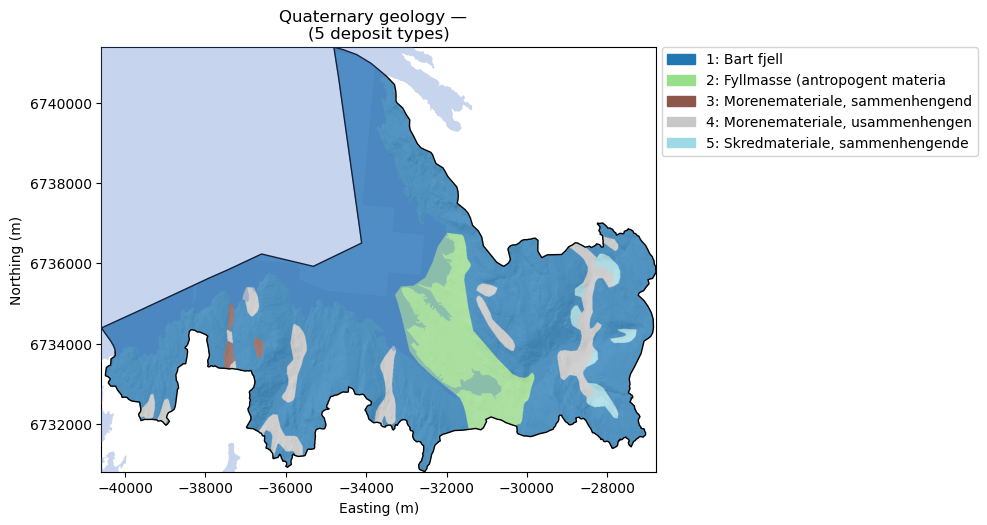

In [63]:
n_types  = len(rock_to_id)
cmap_geo = plt.cm.get_cmap("tab20", n_types)

display_array = np.where(geo_array > 0, geo_array.astype(float), np.nan)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hillshade, cmap="gray", alpha=0.4, extent=extent)
_plot_sea_polygon(ax, alpha=0.30)
ax.imshow(
    display_array,
    cmap=cmap_geo, vmin=0.5, vmax=n_types + 0.5,
    alpha=0.75, extent=extent,
)
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1)

patches_geo = [
    mpatches.Patch(color=cmap_geo(i), label=f"{row['id']}: {str(row['deposit_type'])[:30]}")
    for i, row in legend_df.iterrows()
]
if n_types > 3:
    ax.legend(handles=patches_geo, bbox_to_anchor=(1.01, 1), loc="upper left",
              borderaxespad=0, framealpha=0.85, ncol=max(1, n_types // 12))
else:
    ax.legend(handles=patches_geo, loc="best", framealpha=0.85)

ax.set_title(f"Quaternary geology — {name}\n({n_types} deposit types)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()


## Section 5b — Bedrock Geology (NGU Berggrunn N50)

Bedrock geology for Western Norway is dominated by Precambrian metamorphic gneisses.
This section downloads the **NGU Berggrunn N50** shapefile (1:50 000) directly from
the [NGU GeoNorge Atom feed](https://nedlasting.ngu.no/api/atom/a5c76d05-33bd-4a1d-b28b-81575092e468)
— open data published under the NLOD licence.

### Why Atom feed, not OGC API?

The NGU Berggrunn dataset is served **only as WMS raster tiles** via the live endpoints
(`geo.ngu.no/mapserver/BerggrunnWMS3`). There is **no OGC API Features / WFS** service for
the vector polygon data. The downloadable vector files (Shapefile, FGDB, SOSI) are accessible
through the NGU download API, accessed here via its **Atom feed** — a standards-based
syndication format listing pre-packaged county-level zip files.

### Download strategy

1. Fetch the Atom feed XML → locate the entry for **Vestland county, SHAPE, EPSG:25833**
2. Download the zip (~10–30 MB), extract, open the polygon layer (`*flate*.shp`)
3. Clip to the catchment bounding box; detect the rock-name column (`BERGNAVN` / `HBERGART`)
4. Classify each polygon into a groundwater potential category via keywords
5. A **fallback** (geometric complement) is used if the download fails

### Hydraulic classification of rock types

| Keyword class | K (m/s)   | Examples                          |
|---------------|-----------|-----------------------------------|
| Igneous       | 8 × 10⁻⁷  | Granitt, Gabbro, Basalt           |
| Metamorphic   | 8 × 10⁻⁷  | Gneis, Migmatitt, Marmor          |
| Sedimentary   | 5 × 10⁻⁶  | Sandstein, Kalkstein, Fyllitt     |
| Unknown       | 3 × 10⁻⁶  | default                           |


In [64]:

# Section 5b: Download Berggrunn N50 shapefile via NGU Atom feed
#
# Source  : NGU Berggrunn N50 (1:50 000), open data (NLOD licence)
# Atom feed : https://nedlasting.ngu.no/api/atom/a5c76d05-33bd-4a1d-b28b-81575092e468
# We select : Vestland county · SHAPE format · EPSG:25833

import io, os, glob, zipfile, tempfile, xml.etree.ElementTree as ET
import urllib.request

ATOM_URL      = "https://nedlasting.ngu.no/api/atom/a5c76d05-33bd-4a1d-b28b-81575092e468"
TARGET_COUNTY = "Vestland"    # Bergen catchment sits in Vestland (fylke 46)
TARGET_FORMAT = "SHAPE"
TARGET_EPSG   = "EPSG:25833"  # UTM zone 33N — matches our CRS variable

BEDROCK_ID_OFFSET = 100       # bedrock IDs: 101… (clear of quaternary 1…N)
BEDROCK_TYPE_COL  = "lithology"


def _find_atom_download_url(atom_url, county, fmt, epsg):
    """Parse NGU Atom feed XML; return the download href for the matching entry."""
    with urllib.request.urlopen(atom_url, timeout=30) as resp:
        tree = ET.fromstring(resp.read())
    ns = "http://www.w3.org/2005/Atom"
    for entry in tree.findall(f"{{{ns}}}entry"):
        has_fmt = has_county = has_epsg = False
        for cat in entry.findall(f"{{{ns}}}category"):
            t   = cat.get("term",  "")
            lbl = cat.get("label", "")
            if t == f"Format:{fmt}":
                has_fmt = True
            if t == "Fylke" and lbl == county:
                has_county = True
            if t == epsg:
                has_epsg = True
        if has_fmt and has_county and has_epsg:
            link = entry.find(f"{{{ns}}}link")
            if link is not None:
                return link.get("href")
    return None


bedrock_gdf      = None
bedrock_type_col = None

try:
    # 1. Locate download URL from Atom feed ───────────────────────────────────
    print("Fetching Berggrunn N50 Atom feed …")
    url = _find_atom_download_url(ATOM_URL, TARGET_COUNTY, TARGET_FORMAT, TARGET_EPSG)
    if url is None:
        raise RuntimeError(
            f"No Atom entry found for county={TARGET_COUNTY}, "
            f"format={TARGET_FORMAT}, CRS={TARGET_EPSG}"
        )
    print(f"  Download URL : {url}")

    # 2. Download zip ──────────────────────────────────────────────────────────
    print("  Downloading shapefile zip (may take ~30 s) …")
    with urllib.request.urlopen(url, timeout=300) as resp:
        zip_bytes = resp.read()
    print(f"  Downloaded   : {len(zip_bytes) / 1e6:.1f} MB")

    # 3. Extract to temp dir ──────────────────────────────────────────────────
    tmpdir = tempfile.mkdtemp(prefix="berggrunn_n50_")
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        zf.extractall(tmpdir)
    shp_files = sorted(glob.glob(os.path.join(tmpdir, "**", "*.shp"), recursive=True))
    print(f"  Shapefiles   : {[os.path.basename(s) for s in shp_files]}")

    # 4. Select polygon (flate / area) layer ──────────────────────────────────
    flate_shps = [s for s in shp_files if "flate" in os.path.basename(s).lower()]
    target_shp = flate_shps[0] if flate_shps else shp_files[0]
    print(f"  Using        : {os.path.basename(target_shp)}")

    # 5. Read and quick-clip to catchment bbox ────────────────────────────────
    raw_gdf = gpd.read_file(target_shp)
    print(f"  Raw features : {len(raw_gdf)}  |  CRS: {raw_gdf.crs}")
    print(f"  Columns      : {list(raw_gdf.columns)}")

    from shapely.geometry import box as sg_box
    bounds = catchment_gdf.to_crs(raw_gdf.crs).total_bounds
    cx  = (bounds[0] + bounds[2]) / 2
    cy  = (bounds[1] + bounds[3]) / 2
    buf = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 0.6
    clip_box = sg_box(cx - buf, cy - buf, cx + buf, cy + buf)
    rock_gdf = raw_gdf[raw_gdf.intersects(clip_box)].copy()
    print(f"  After bbox clip : {len(rock_gdf)} features")

    # 6. Detect lithology-name column ─────────────────────────────────────────
    _CAND_COLS = ["tegnforkla", "tegnfo_eng", "TEGNFORKLA", "TEGNFO_ENG",
                  "BERGNAVN", "HBERGART", "bergnavn", "hbergart",
                  "BERGKODE", "bergkode", "BERGTYPE", "bergtype", "description"]
    _SKIP_COLS = {"geometry", "lokalid", "objectid", "fid", "shape_area",
                  "objtype", "opphav", "mref", "kartbladin", "datauttaks",
                  "oppdaterin", "rgbfargeko", "cmykfargek"}
    name_col = None
    for cand in _CAND_COLS:
        matched = [c for c in rock_gdf.columns if c.lower() == cand.lower()]
        if matched:
            name_col = matched[0]
            break
    if name_col is None:
        for c in rock_gdf.columns:
            if (c.lower() not in _SKIP_COLS
                    and rock_gdf[c].dtype == object
                    and rock_gdf[c].nunique() > 1):
                name_col = c
                break
    if name_col is None:
        raise RuntimeError(
            f"Could not identify a lithology column. "
            f"Available columns: {list(rock_gdf.columns)}"
        )
    print(f"  Lithology column : '{name_col}'")
    unique_vals = sorted(rock_gdf[name_col].dropna().unique())
    print(f"  Unique values ({len(unique_vals)}) :")
    for v in unique_vals:
        print(f"    {v}")

    # 7. Reproject to model CRS and store raw lithology name ──────────────────
    rock_gdf = rock_gdf.to_crs(CRS)
    rock_gdf[BEDROCK_TYPE_COL] = rock_gdf[name_col].fillna("").str.strip()

    # 8. Clip to catchment polygon ────────────────────────────────────────────
    catch_geom = catchment_gdf.geometry.to_crs(CRS).union_all()
    rock_gdf   = gpd.clip(rock_gdf, catch_geom).copy()
    rock_gdf   = rock_gdf[~rock_gdf.is_empty & rock_gdf.geometry.notna()].copy()

    if rock_gdf.empty:
        raise RuntimeError("No bedrock polygons remain after clipping to catchment.")

    bedrock_gdf      = rock_gdf
    bedrock_type_col = BEDROCK_TYPE_COL

    area_km2  = bedrock_gdf.geometry.area.sum() / 1e6
    catch_km2 = catch_geom.area / 1e6
    print(f"\nBerggrunn N50 loaded:")
    print(f"  {len(bedrock_gdf)} polygon(s) within catchment")
    print(f"  Total area : {area_km2:.2f} km\u00b2  ({100 * area_km2 / catch_km2:.0f}% of catchment)")
    print(f"  Lithology units : {bedrock_gdf[BEDROCK_TYPE_COL].nunique()} distinct types")

except Exception as exc:
    import traceback
    print(f"\nBerggrunn N50 download/load failed: {exc}")
    traceback.print_exc()
    print("\nFalling back to quaternary-complement approach …")

    try:
        from shapely.geometry import Polygon, MultiPolygon
        quat_union = geology_gdf.geometry.union_all()
        catch_geom = catchment_gdf.geometry.to_crs(CRS).union_all()
        bare_rock  = catch_geom.difference(quat_union)

        if bare_rock.is_empty:
            raise ValueError(
                "Quaternary covers entire catchment — no bare rock complement."
            )

        def _geom_parts(g):
            if g.geom_type == "MultiPolygon":
                return list(g.geoms)
            if g.geom_type == "Polygon":
                return [g]
            return [p for p in g.geoms
                    if p.geom_type in ("Polygon", "MultiPolygon") and not p.is_empty]

        parts = _geom_parts(bare_rock)
        BARE_LABEL = "Bart fjell"
        bedrock_gdf = gpd.GeoDataFrame(
            {BEDROCK_TYPE_COL: [BARE_LABEL] * len(parts)},
            geometry=parts, crs=CRS,
        )
        bedrock_type_col = BEDROCK_TYPE_COL
        print(f"  Fallback OK: {len(bedrock_gdf)} bare-rock polygon(s)")
    except Exception as exc2:
        print(f"  Fallback also failed: {exc2}")
        bedrock_gdf      = None
        bedrock_type_col = None


Fetching Berggrunn N50 Atom feed …
  Download URL : https://nedlasting.ngu.no/api/fileproxy/a5c76d05-33bd-4a1d-b28b-81575092e468/190b557a-268d-41de-9ff9-d7bc2f00b0d0
  Downloaded   : 30.6 MB
  Shapefiles   : ['BergartFlate_N50.shp', 'BergartGrense_N50.shp', 'Bergartslinje_N50.shp', 'Linearstruktur_N50.shp', 'StrukturMalePkt_N50.shp']
  Using        : BergartFlate_N50.shp
  Raw features : 11115  |  CRS: EPSG:25833
  Columns      : ['objtype', 'hovedberg', 'hovedberg_', 'tegnforkla', 'tegnfo_eng', 'tegnfor_nr', 'opphav', 'rgbfargeko', 'cmykfargek', 'mref', 'kartbladin', 'tekthoved', 'tekthoved_', 'tillegbrg1', 'tillegbr1_', 'tillegbrg2', 'tillebrg2_', 'tillebrg3_', 'tillegbrg3', 'tektenhet', 'tektenhet_', 'dekkekompl', 'dekkekomp_', 'dekke', 'dekke_navn', 'overgruppe', 'overgrupp_', 'gruppe', 'gruppe_', 'formasjon', 'formasjon_', 'kompleks', 'kompleks_', 'suite', 'suite_', 'litodem', 'litodem_', 'geolform', 'geolform_', 'alder', 'alder_', 'minalder', 'minalder_', 'maksalder', 'maksalder_

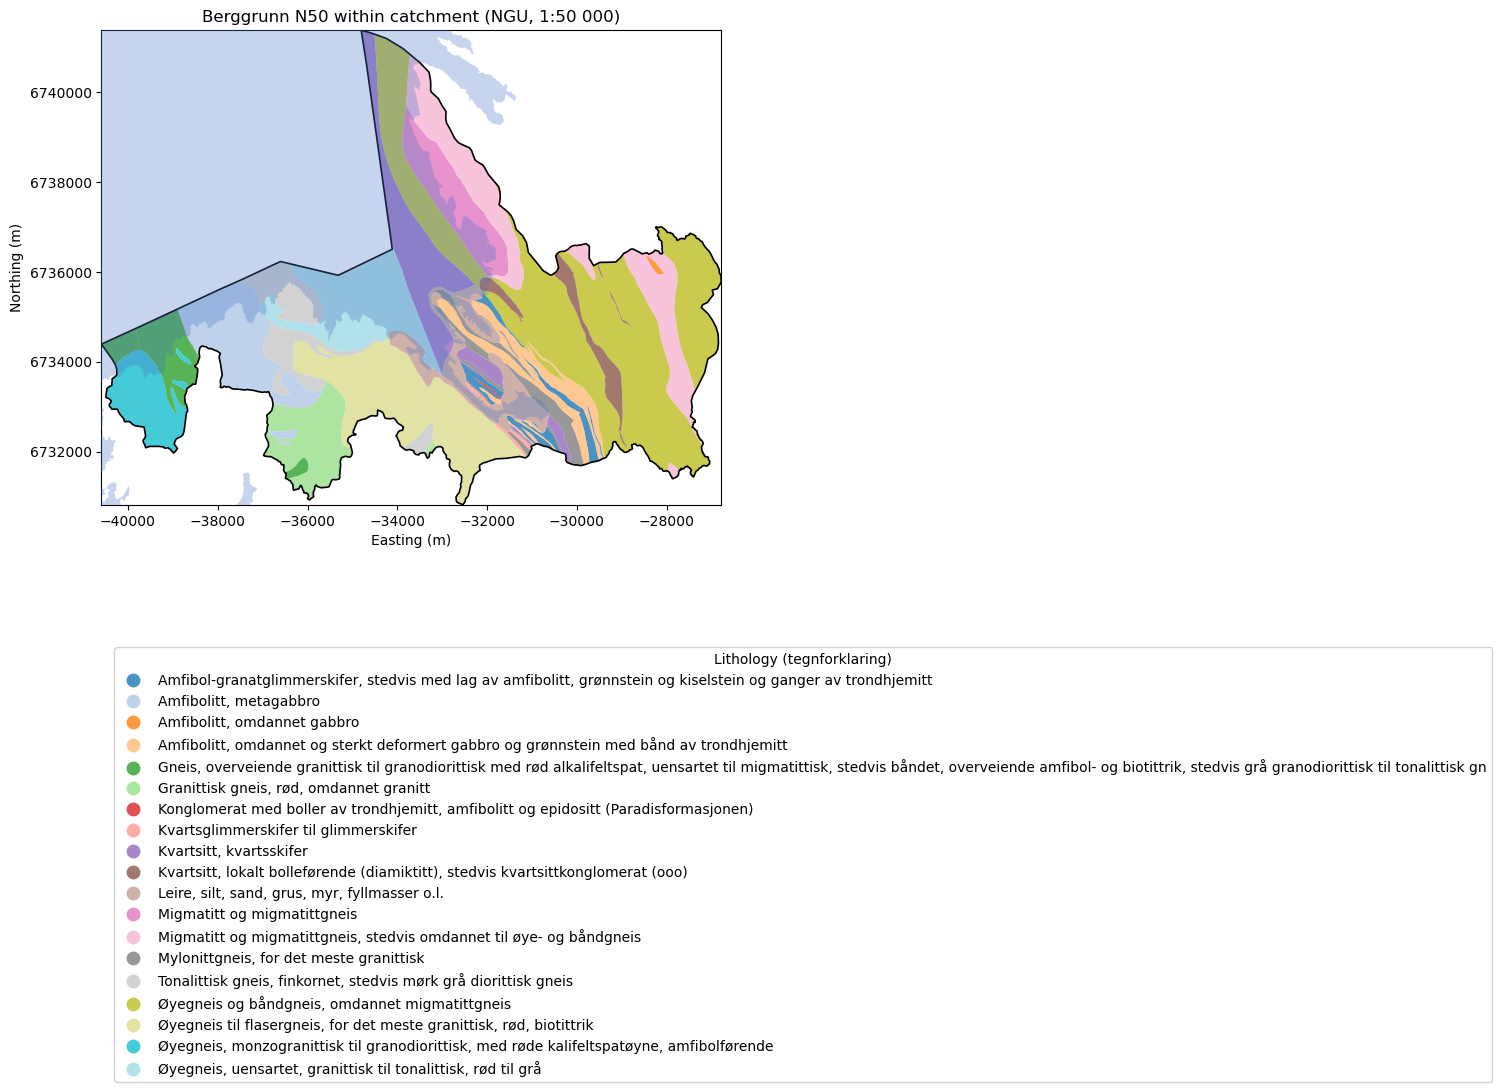

In [65]:
# ─── Plot: Berggrunn N50 lithology ────────────────────────────────────────────
if bedrock_gdf is not None and bedrock_type_col is not None:
    _bed_types = sorted(bedrock_gdf[bedrock_type_col].dropna().unique())
    n_bed      = len(_bed_types)
    _cmap_bed  = plt.colormaps.get_cmap("tab20").resampled(n_bed)

    _lgd_kwds = {"title": "Lithology (tegnforklaring)", "framealpha": 0.9}
    if n_bed > 3:
        _lgd_kwds.update({"bbox_to_anchor": (0.02, -0.3), "loc": "upper left",
                           "borderaxespad": 0})
    else:
        _lgd_kwds["loc"] = "best"

    fig, ax = plt.subplots(figsize=(8, 15))
    _plot_sea_polygon(ax, alpha=0.30)
    catchment_gdf.to_crs(CRS).boundary.plot(ax=ax, color="black", linewidth=1.2)
    bedrock_gdf.plot(column=bedrock_type_col, ax=ax, alpha=0.8,
                     cmap=_cmap_bed, legend=True, legend_kwds=_lgd_kwds)
    ax.set_title("Berggrunn N50 within catchment (NGU, 1:50 000)")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain", axis="both")
    _limit_axes_to_catchment(ax)
    #plt.tight_layout()
    plt.show()


In [87]:
# Section 5b (continued): rasterize bedrock lithology and merge with quaternary geology

if bedrock_gdf is not None and bedrock_type_col is not None:

    # ── Assign integer IDs (OFFSET + sequential integer) ─────────────
    unique_bedrock = sorted(bedrock_gdf[bedrock_type_col].dropna().unique())
    bedrock_to_id  = {bt: BEDROCK_ID_OFFSET + i + 1
                      for i, bt in enumerate(unique_bedrock)}
    bedrock_gdf["bedrock_id"] = (
        bedrock_gdf[bedrock_type_col].map(bedrock_to_id).fillna(0).astype(int)
    )

    # ── Build bedrock legend (raw lithology only) ─────────────────────
    bedrock_legend_rows = []
    for bt, bid in bedrock_to_id.items():
        bedrock_legend_rows.append({
            "id":           bid,
            "deposit_type": bt,
            "source":       "berggrunn_n50",
        })
    bedrock_legend_df = (
        pd.DataFrame(bedrock_legend_rows)
        .sort_values("id")
        .reset_index(drop=True)
    )

    # ── Rasterize bedrock polygons onto the master grid ───────────────
    bedrock_array = np.zeros(master_shape, dtype=np.int16)
    bed_shapes = [
        (geom, int(bid))
        for geom, bid in zip(bedrock_gdf.geometry, bedrock_gdf["bedrock_id"])
        if geom is not None and not geom.is_empty
    ]
    rasterio.features.rasterize(
        shapes=bed_shapes,
        out=bedrock_array,
        transform=master_transform,
        fill=0,
        dtype=np.int16,
    )

    # ── Save standalone bedrock raster ───────────────────────────────
    bed_profile = {
        "driver": "GTiff", "dtype": "int16",
        "height": master_shape[0], "width": master_shape[1],
        "count": 1, "crs": master_crs, "transform": master_transform,
        "nodata": 0, "compress": "lzw",
    }
    bedrock_path = OUTPUT_DIR / "bedrock.tif"
    with rasterio.open(bedrock_path, "w", **bed_profile) as dst:
        dst.write(bedrock_array, 1)

    bedrock_legend_path = OUTPUT_DIR / "bedrock_legend.csv"
    bedrock_legend_df.to_csv(bedrock_legend_path, index=False, encoding="utf-8")

    print(f"Bedrock raster saved  → {bedrock_path}")
    print(f"Bedrock legend saved  → {bedrock_legend_path}")
    print(f"  {int((bedrock_array > 0).sum()):,} bedrock pixels")
    print(bedrock_legend_df.to_string(index=False))

    # ── Identify "Bart fjell" cells in the løsmasse layer ─────────────
    # "Bart fjell" (bare-rock outcrop) is mapped in NGU Løsmasse Regionalt as
    # a special category meaning "no loose deposits present". For groundwater
    # modelling these cells are hydraulically bedrock, so we replace them with
    # the actual bedrock lithology from Berggrunn N50.
    _bart_ids = legend_df.loc[
        legend_df["deposit_type"].str.lower().str.strip() == "bart fjell", "id"
    ].tolist()
    _no_quat = (geo_array == 0)
    for _bid in _bart_ids:
        _no_quat = _no_quat | (geo_array == int(_bid))
    if _bart_ids:
        print(f"\n  'Bart fjell' løsmasse ID(s) {_bart_ids} will be replaced by bedrock lithology.")

    # ── Merge: bedrock fills uncovered and Bart-fjell land cells ──────
    # Sea cells (fjords, ocean) are excluded so they stay at nodata in geology.tif.
    _land = (sea_array == 0) if "sea_array" in vars() else np.ones(master_shape, dtype=bool)
    n_uncovered_before = int((_no_quat & _land).sum())
    geo_combined = np.where(
        _no_quat & (bedrock_array > 0) & _land,
        bedrock_array,
        np.where(_no_quat, 0, geo_array),  # zero out uncovered cells (no bedrock + no quaternary)
    ).astype(np.int16)
    n_filled          = int(np.sum(_no_quat & (bedrock_array > 0) & _land))
    n_uncovered_after = int((_no_quat & _land & (bedrock_array == 0)).sum())

    print(f"\n  Cells to fill (no quaternary + Bart fjell) : {n_uncovered_before:,}")
    print(f"  Cells filled with bedrock                  : {n_filled:,}")
    print(f"  Still uncovered (bedrock data gap)         : {n_uncovered_after:,}")

    # ── Overwrite geology.tif with combined raster ─────────────────────
    with rasterio.open(geo_path, "w", **geo_profile) as dst:
        dst.write(geo_combined, 1)

    # ── Overwrite geology_legend.csv with combined legend ──────────────
    # Exclude "Bart fjell" from the løsmasse legend if all its cells were replaced.
    legend_df_combined = legend_df.copy()
    legend_df_combined["source"] = "losmasse"
    if _bart_ids and n_filled > 0:
        # Remove Bart fjell entries that are now fully replaced by bedrock
        legend_df_combined = legend_df_combined[
            ~legend_df_combined["id"].isin(_bart_ids)
        ].reset_index(drop=True)

    combined_legend = pd.concat(
        [legend_df_combined, bedrock_legend_df], ignore_index=True
    )
    combined_legend.to_csv(legend_path, index=False, encoding="utf-8")

    # ── Refresh display variables from the merged geology ──────────────────────
    # Update display_array, patches_geo, n_types and cmap_geo from combined_legend
    # and geo_combined so that the final summary plot shows all deposit types.
    _id_to_seq = {int(r['id']): i + 1 for i, r in combined_legend.reset_index(drop=True).iterrows()}
    n_types = len(combined_legend)
    if n_types <= 20:
        cmap_geo = plt.cm.get_cmap('tab20', n_types)
    else:
        from matplotlib.colors import ListedColormap as _LC2
        _colors2 = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
        cmap_geo = _LC2(_colors2[:n_types])
    display_array = np.full(master_shape, np.nan, dtype=float)
    for _oid, _sid in _id_to_seq.items():
        display_array[geo_combined == _oid] = _sid
    patches_geo = [
        mpatches.Patch(
            color=cmap_geo(_i / n_types),
            label=f"{int(_r['id'])}: {str(_r['deposit_type'])[:40]}",
        )
        for _i, _r in combined_legend.reset_index(drop=True).iterrows()
    ]

    print(f"\nUpdated geology.tif        → {geo_path}")
    print(f"Updated geology_legend.csv → {legend_path}")
    print(f"  {len(combined_legend)} total entries "
          f"({len(legend_df_combined)} løsmasse + {len(bedrock_legend_df)} bedrock)")

else:
    print("Bedrock merge skipped (no data). geology.tif is unchanged.")
    geo_combined = geo_array.copy()


Bedrock raster saved  → data/model_input/bedrock.tif
Bedrock legend saved  → data/model_input/bedrock_legend.csv
  615,169 bedrock pixels
 id                                                                                                                                                                                             deposit_type        source
101                                                                                           Amfibol-granatglimmerskifer, stedvis med lag av amfibolitt, grønnstein og kiselstein og ganger av trondhjemitt berggrunn_n50
102                                                                                                                                                                                   Amfibolitt, metagabbro berggrunn_n50
103                                                                                                                                                                              Amfibolitt, omdannet gabbro 

## Section 6 — Groundwater Recharge

Recharge is read from a user-supplied raster (`RECHARGE_INPUT_PATH`).
If that file does not exist the cell falls back to a spatially uniform constant rate
(`DEFAULT_NET_RECHARGE_MM_YR`).

### User-supplied raster
Place any GeoTIFF with recharge values in **mm/year** at the path set by
`RECHARGE_INPUT_PATH`.  The file may be in any CRS and at any resolution — it will
be reprojected and resampled to the master grid automatically.

### Fallback constant
When the file is absent a uniform value of `DEFAULT_NET_RECHARGE_MM_YR` mm/yr
(default **300 mm/yr**) is used for the entire catchment.

### Outputs
- `recharge_mm_yr.tif` — recharge in mm/year on the master grid
- `recharge_m_s.tif`   — same recharge in m/s (ready for MODFLOW RCH)


In [67]:

# ── User configuration ────────────────────────────────────────────────────────
# Path to an optional user-supplied recharge raster (mm/yr, any CRS/resolution).
# Set to a non-existent path (or None) to use the constant fallback below.
RECHARGE_INPUT_PATH        = Path("data/norway_recharge_mm_yr.tif")
DEFAULT_NET_RECHARGE_MM_YR = 300.0   # mm/yr used when RECHARGE_INPUT_PATH is absent

# ── Load or build recharge array ─────────────────────────────────────────────
from rasterio.warp import reproject, Resampling

if RECHARGE_INPUT_PATH is not None and Path(RECHARGE_INPUT_PATH).exists():
    print(f"Reading recharge from {RECHARGE_INPUT_PATH} …")
    with rasterio.open(RECHARGE_INPUT_PATH) as src:
        raw = src.read(1).astype(np.float32)
        nd  = src.nodata
        if nd is not None:
            raw[raw == nd] = np.nan

        recharge_mm_yr = np.full(master_shape, np.nan, dtype=np.float32)
        reproject(
            source        = raw,
            destination   = recharge_mm_yr,
            src_transform = src.transform,
            src_crs       = src.crs,
            dst_transform = master_transform,
            dst_crs       = master_crs,
            resampling    = Resampling.bilinear,
            src_nodata    = np.nan,
            dst_nodata    = np.nan,
        )
    recharge_source = f"user raster: {RECHARGE_INPUT_PATH}"
    print(f"  Reprojected to master grid ({master_shape[0]} x {master_shape[1]})")
else:
    print(f"Recharge input file not found — using constant {DEFAULT_NET_RECHARGE_MM_YR:.1f} mm/yr")
    recharge_mm_yr  = np.full(master_shape, DEFAULT_NET_RECHARGE_MM_YR, dtype=np.float32)
    recharge_source = f"constant {DEFAULT_NET_RECHARGE_MM_YR:.1f} mm/yr (fallback)"

# ── Mask to valid topography ──────────────────────────────────────────────────
recharge_mm_yr = np.where(np.isfinite(elevation), recharge_mm_yr, np.nan).astype(np.float32)

# ── Convert to m/s ────────────────────────────────────────────────────────────
seconds_per_year = 365.25 * 24.0 * 3600.0
recharge_m_s     = (recharge_mm_yr / 1000.0) / seconds_per_year

# ── Save rasters ──────────────────────────────────────────────────────────────
recharge_profile = {
    "driver": "GTiff", "dtype": "float32",
    "height": master_shape[0], "width": master_shape[1],
    "count": 1, "crs": master_crs, "transform": master_transform,
    "nodata": np.nan, "compress": "lzw",
}
recharge_mm_path = OUTPUT_DIR / "recharge_mm_yr.tif"
recharge_ms_path = OUTPUT_DIR / "recharge_m_s.tif"

with rasterio.open(recharge_mm_path, "w", **recharge_profile) as dst:
    dst.write(recharge_mm_yr, 1)
with rasterio.open(recharge_ms_path, "w", **recharge_profile) as dst:
    dst.write(recharge_m_s.astype(np.float32), 1)

print(f"\nRecharge rasters saved:")
print(f"  {recharge_mm_path}")
print(f"  {recharge_ms_path}")
print(f"  Source  : {recharge_source}")
print(f"  mm/yr   : min={np.nanmin(recharge_mm_yr):.1f}, "
      f"max={np.nanmax(recharge_mm_yr):.1f}, mean={np.nanmean(recharge_mm_yr):.1f}")
print(f"  m/s     : min={np.nanmin(recharge_m_s):.3e}, "
      f"max={np.nanmax(recharge_m_s):.3e}, mean={np.nanmean(recharge_m_s):.3e}")


Recharge input file not found — using constant 300.0 mm/yr

Recharge rasters saved:
  data/model_input/recharge_mm_yr.tif
  data/model_input/recharge_m_s.tif
  Source  : constant 300.0 mm/yr (fallback)
  mm/yr   : min=300.0, max=300.0, mean=300.0
  m/s     : min=9.506e-09, max=9.506e-09, mean=9.506e-09


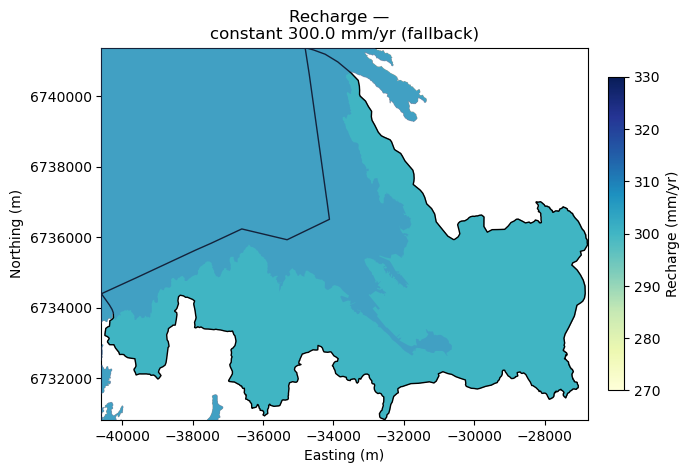

In [68]:
# ─── Plot: recharge ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(recharge_mm_yr, cmap="YlGnBu", extent=extent)
_plot_sea_polygon(ax, alpha=0.30)
catchment_gdf.boundary.plot(ax=ax, color="black", linewidth=1.0)
plt.colorbar(im, ax=ax, label="Recharge (mm/yr)", fraction=0.03, pad=0.04)
ax.set_title(f"Recharge — {name}\n{recharge_source}")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.ticklabel_format(style="plain", axis="both")
_limit_axes_to_catchment(ax)
plt.tight_layout()
plt.show()


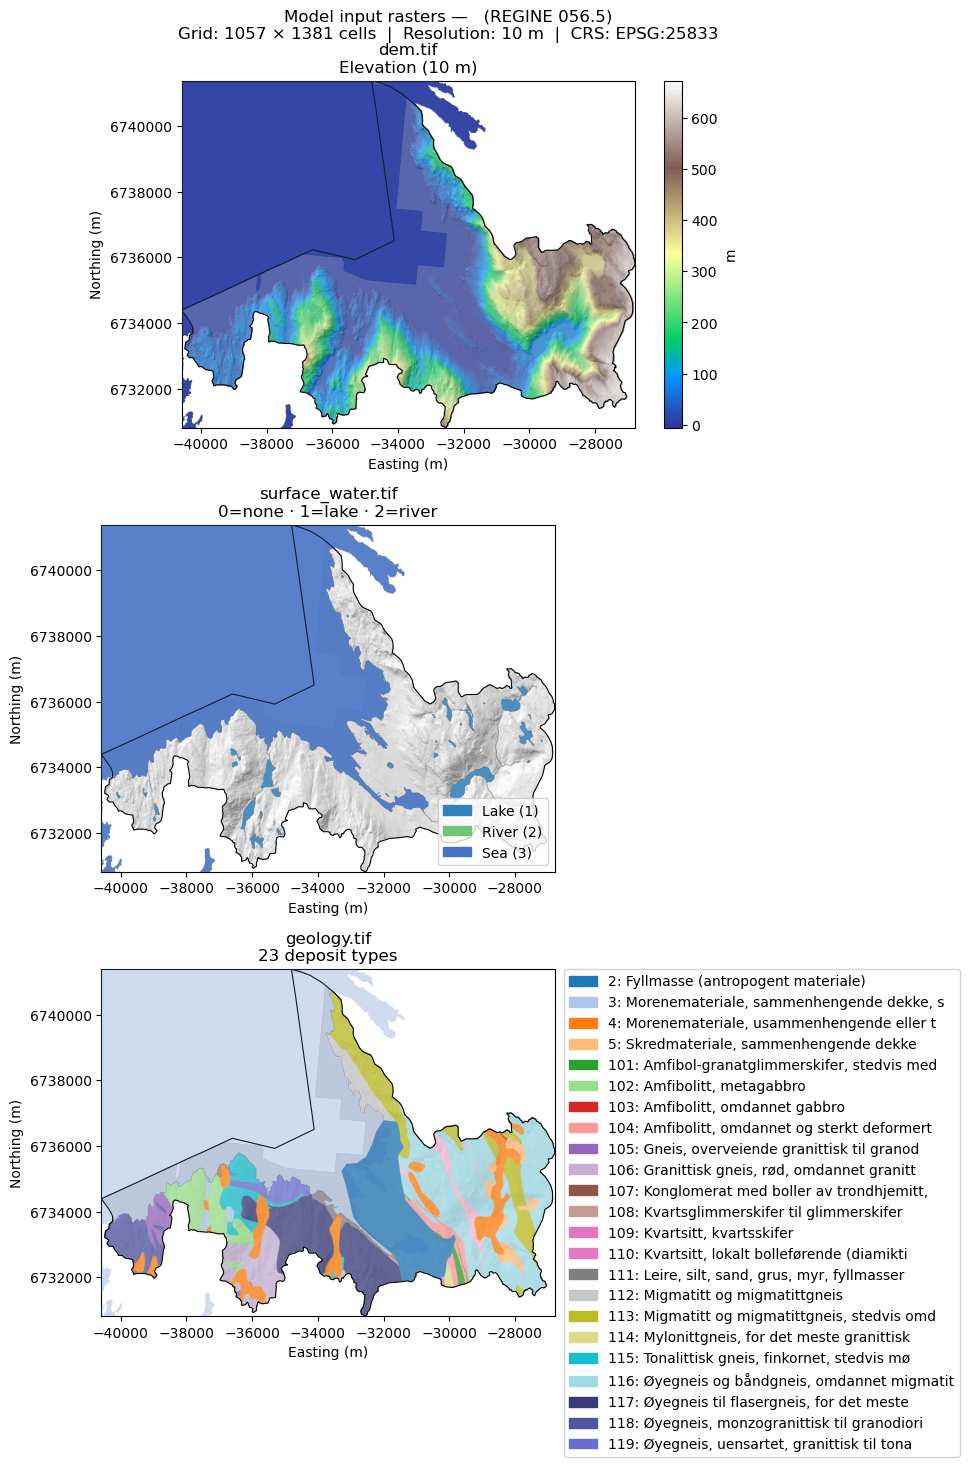

In [88]:
# ── Refresh geology display from the saved files (always up-to-date) ─────────
# Read geology.tif and its legend directly from disk rather than relying on
# in-memory variables that may reflect a pre-merge state.
with rasterio.open(geo_path) as _gsrc:
    _geo_disp_src = _gsrc.read(1)
_leg_src = pd.read_csv(legend_path).reset_index(drop=True)
n_types = len(_leg_src)
if n_types <= 20:
    cmap_geo = plt.cm.get_cmap("tab20", n_types)
else:
    from matplotlib.colors import ListedColormap as _LC
    _colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
    cmap_geo = _LC(_colors[:n_types])
# Remap non-sequential IDs (e.g. 2-5, 101-119) to sequential 1..n_types
_id_to_seq = {int(r["id"]): i + 1 for i, r in _leg_src.iterrows()}
display_array = np.full(_geo_disp_src.shape, np.nan, dtype=float)
for _orig_id, _seq_id in _id_to_seq.items():
    display_array[_geo_disp_src == _orig_id] = _seq_id
patches_geo = [
    mpatches.Patch(
        color=cmap_geo(i / n_types),
        label=f"{int(r['id'])}: {str(r['deposit_type'])[:40]}",
    )
    for i, r in _leg_src.iterrows()
]

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    f"Model input rasters — {name} (REGINE {reg_id})\n"
    f"Grid: {master_shape[0]} × {master_shape[1]} cells  |  "
    f"Resolution: {TARGET_RESOLUTION} m  |  CRS: {master_crs}",
)

# 1. DEM
im0 = axes[0].imshow(elevation, cmap="terrain", extent=extent)
axes[0].imshow(hillshade, cmap="gray", alpha=0.35, extent=extent)
_plot_sea_polygon(axes[0], alpha=0.25)
catchment_gdf.boundary.plot(ax=axes[0], color="black", linewidth=0.8)
plt.colorbar(im0, ax=axes[0], label="m", fraction=0.04, pad=0.04)
axes[0].set_title(f"dem.tif\nElevation ({TARGET_RESOLUTION} m)")

# 2. Surface water
axes[1].imshow(hillshade, cmap="gray", alpha=0.5, extent=extent)
_plot_sea_polygon(axes[1], alpha=0.25)
axes[1].imshow(
    np.where(sw_array > 0, sw_array.astype(float), np.nan),
    cmap=cmap_sw, norm=norm_sw, alpha=0.85, extent=extent,
)
catchment_gdf.boundary.plot(ax=axes[1], color="black", linewidth=0.8)
axes[1].legend(handles=patches_sw, loc="lower right")
axes[1].set_title("surface_water.tif\n0=none · 1=lake · 2=river")

# 3. Geology (from saved geology.tif + geology_legend.csv)
axes[2].imshow(hillshade, cmap="gray", alpha=0.35, extent=extent)
_plot_sea_polygon(axes[2], alpha=0.25)
axes[2].imshow(
    display_array,
    cmap=cmap_geo, vmin=0.5, vmax=n_types + 0.5,
    alpha=0.75, extent=extent,
)
catchment_gdf.boundary.plot(ax=axes[2], color="black", linewidth=0.8)
if n_types > 3:
    axes[2].legend(handles=patches_geo, bbox_to_anchor=(1.02, 1), loc="upper left",
                   borderaxespad=0, framealpha=0.85, ncol=max(1, n_types // 12))
else:
    axes[2].legend(handles=patches_geo, loc="best", framealpha=0.85)
axes[2].set_title(f"geology.tif\n{n_types} deposit types")

for ax in axes.flat:
    if ax.get_visible():
        ax.set_xlabel("Easting (m)")
        ax.ticklabel_format(style="plain", axis="both")
        _limit_axes_to_catchment(ax)
    ax.set_ylabel("Northing (m)")
axes[2].set_xlabel("Easting (m)")

plt.tight_layout()
plt.show()


In [70]:
print("=" * 68)
print(f"  Catchment  : {name}  (REGINE {reg_id})")
print(f"  Area       : {area_km2:.1f} km²")
print(f"  CRS        : {master_crs}")
print(f"  Grid size  : {master_shape[0]} rows × {master_shape[1]} cols")
print(f"  Resolution : {TARGET_RESOLUTION} m\n")

output_files = [
    ("dem.tif",            "float32", f"elevation min={np.nanmin(elevation):.0f} m, max={np.nanmax(elevation):.0f} m"),
    ("surface_water.tif",  "int16",   f"0/1/2  (lake pixels: {np.sum(sw_array==1):,}, river pixels: {np.sum(sw_array==2):,})"),
    ("geology.tif",        "int16",   f"1–{len(rock_to_id)} ({len(unique_ids)} unit(s) present in raster)"),
    ("geology_legend.csv", "CSV",     f"{len(legend_df)} deposit type(s) with id/deposit_type/gw_potential/inf_potential"),
    ("recharge_mm_yr.tif", "float32", "effective recharge (mm/yr)"),
    ("recharge_m_s.tif",   "float32", "effective recharge (m/s)"),
    ("sea.tif",            "int16",   f"0/1  (sea: {n_sea:,}, land: {n_land:,})"),
    ("catchment.geojson",  "GeoJSON", "catchment boundary polygon"),
]

bedrock_rgb_path = OUTPUT_DIR / "bedrock_hovedbergart_rgb.tif"
if bedrock_rgb_path.exists():
    output_files.append(("bedrock_hovedbergart_rgb.tif", "uint8 x3", "optional NGU rendered bedrock RGB layer"))

print(f"  {'File':<26} {'Type':<10} {'Contents / stats'}")
print(f"  {'-'*26} {'-'*10} {'-'*34}")
for fname, ftype, desc in output_files:
    fpath = OUTPUT_DIR / fname
    size  = f"({fpath.stat().st_size / 1024:.0f} KB)" if fpath.exists() else "(not found)"
    print(f"  {fname:<26} {ftype:<10} {desc}  {size}")

print("=" * 68)
print(f"\nAll files in: {OUTPUT_DIR.resolve()}")

  Catchment  :    (REGINE 056.5)
  Area       : 61.5 km²
  CRS        : EPSG:25833
  Grid size  : 1057 rows × 1381 cols
  Resolution : 10 m

  File                       Type       Contents / stats
  -------------------------- ---------- ----------------------------------
  dem.tif                    float32    elevation min=-6 m, max=673 m  (2007 KB)
  surface_water.tif          int16      0/1/2  (lake pixels: 17,963, river pixels: 1,160)  (110 KB)
  geology.tif                int16      1–5 (5 unit(s) present in raster)  (187 KB)
  geology_legend.csv         CSV        5 deposit type(s) with id/deposit_type/gw_potential/inf_potential  (2 KB)
  recharge_mm_yr.tif         float32    effective recharge (mm/yr)  (330 KB)
  recharge_m_s.tif           float32    effective recharge (m/s)  (332 KB)
  sea.tif                    int16      0/1  (sea: 545,861, land: 913,856)  (102 KB)
  catchment.geojson          GeoJSON    catchment boundary polygon  (41 KB)
  bedrock_hovedbergart_rgb.tif uint